## 📌 프로젝트 목표
호텔 관리인으로서 예약 취소와 관련이 있는 요소들을 파악해보고, 예약 취소율을 줄이기 위한 아이디어를 도출한다. 

## 📊 데이터 설명

| 컬럼명 | 설명 | 유형 | 
|---|---|---|
| hotel | 호텔명 (Resort Hotel 혹은 City Hotel) | 범주형(Resort Hotel, City Hotel) | 
| is_canceled | 호텔 예약이 취소되었는지(1) 혹은 취소되지 않았는지(0)를 나타내는 값 | 범주형(0,1) |
| lead_time | 호텔 예약 시점부터 고객의 호텔 도착 시점까지의 기간 (단위: 날짜) | 이산형(날짜) |
| arrival_date_year | 고객의 호텔 도착 연도 | 이산형(연도) | 
| arrival_date_month | 고객의 호텔 도착 월 | 이산형(월) | 
| arrival_date_week_number | 고객의 호텔 도착 주<br>(예시: 2015년도 셋째 주에 도착 → arrival_date_week_number = 3) | 이산형(주) | 
| arrival_date_day_of_month | 고객의 호텔 도착 일<br>(예시: 3월 2일에 도착 → arrival_date_day_of_month = 2) | 이산형(1~31) |
| stays_in_weekend_nights | 고객이 호텔에 숙박했거나 예약한 주말 밤 수(토요일~일요일)<br>(예시: 평일 3일 주말 2일 예약한 경우 → stays_in_weekend_nights = 2) | 이산형 |
| stays_in_week_nights | 고객이 호텔에 숙박했거나 예약한 주중 밤 수(월요일~금요일)<br>(예시: 평일 3일 주말 2일 예약한 경우 → stays_in_week_nights = 3) | 이산형 | 
| adults | 예약된 어른의 수 | 이산형 | 
| children | 예약된 어린이의 수 | 이산형 | 
| babies | 예약된 아기의 수 | 이산형 |
| meal | 예약된 식사 유형<br>- Undefined/SC: 식사 포함되지 않은 옵션<br>- BB: Bed & Breakfast 옵션<br>- HB: Half board (아침 식사 및 추가 식사 1회 - 일반적으로 저녁 식사) 옵션<br>- FB: Full board (아침, 점심, 저녁) | 범주형(SC, BB, HB, FB) |
| country | 투숙객의 출신 국가. 카테고리는 ISO 3155-3:2013 형식으로 표시<br>(국가 표기 코드는 링크 참조) | 범주형 |
| market_segment | 시장 세그먼트. "TA"는 "Travel Agent", "TO"는 "Tour Operators"를 의미. | 범주형 |
| distribution_channel | 예약 유통 채널. "TA"는 "Travel Agent", "TO"는 "Tour Operators"를 의미. | 범주형 |
| is_repeated_guest | 이전에 방문을 하였던 손님인지(1) 아닌지(0)를 나타나는 값 | 범주형 (0,1) |
| previous_cancellations | 현재 예약 이전에 고객이 취소한 이전 예약 수 | 이산형 |
| previous_bookings_not_canceled | 현재 예약 이전에 고객이 취소하지 않은 이전 예약 수 | 이산형 |
| reserved_room_type | 예약한 룸 타입 코드 | 범주형 |
| assigned_room_type | 배정된 룸 타입 코드. 호텔 운영상의 이유(ex. 초과 예약 등) 또는 고객 요청으로 인해 예약한 객실과 다른 객실 유형이 배정되는 경우가 존재. | 범주형 |
| booking_changes | 예약 시점부터 예약 취소/체크인 시점까지 에약에 대한 변경/수정 횟수 | 이산형 |
| agent | 예약을 진행한 여행사의 ID | 이산형 |
| company | 예약을 하였거나 예약금을 지불할 책임이 있는 회사 또는 단체의 ID | 이산형 |
| days_in_waiting_list | 예약이 확정되기 전까지 해당 예약이 예약 대기자 명단에 있었던 일수 | 이산형 |
| required_car_parking_spaces | 고객이 요구하는 주차 공간 수 | 이산형 |
| total_of_special_requests | 고객의 특별 요청 건수 (ex. 트윈 베드, 아기 침대, 고층, 특별한 뷰 등) | 이산형 |
| reservation_status | 예약의 마지막 상태, 총 3가지 카테고리로 구성<br>- Canceled: 고객이 예약을 취소함<br>- Check-Out: 고객이 체크인을 하고 체크아웃을 함<br>- No-Show: 노쇼. 고객이 체크인을 하지 않았고 해당 이유를 알 수 없음. | 범주형(Canceled, Check-Out, No-Show) |
| reservations_status_date | 마지막 예약 상태(reservation_status)가 설정된 날짜. | 이산형(날짜) |

## 목차
1. 결측치 처리
2. 논리적 오류 행 처리
3. 컬럼 유형별 인사이트 도출
4. 데이터 해석

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [211]:
full_data = pd.read_csv("./hotel_data_modified.csv")

In [212]:
display(full_data.describe(include='all'))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,119390,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,10,12,NaN,NaN,NaN,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,A,A,NaN,NaN,NaN,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,85994,74053,NaN,NaN,NaN,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,NaN,0.221124,86.693382,189.266735,2.321149,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,NaN,0.652306,110.774548,131.655015,17.594721,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,NaN,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,NaN,0.000000,9.000000,62.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,NaN,0.000000,14.000000,179.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,NaN,0.000000,229.000000,270.000000,0.000000,0.000000,1.000000,NaN,NaN


## 1. 결측치 처리

In [213]:
# 결측치는 뭐가 있을까?

def get_nan_df(data: pd.DataFrame) -> pd.DataFrame:
    df_summary = pd.DataFrame(
        {
            'dtype': data.dtypes,
            'nan_cnt': data.isna().sum(), # 컬럼 별로 Nan값인 row의 개수
            'nan_percentage': round((data.isna().sum() / len(data)), 5), 
            'first_value': data.iloc[0]        
        }
    ).reset_index().rename(columns={'index': 'col_name'})

    mask = df_summary['nan_cnt'] > 0
    df_cols_have_nan = df_summary[mask][['col_name', 'dtype', 'nan_cnt', 'nan_percentage']]

    return df_cols_have_nan

get_nan_df(full_data)

,col_name,dtype,nan_cnt,nan_percentage
10,children,float64,4,0.00003
13,country,str,488,0.00409
22,agent,float64,16340,0.13686
23,company,float64,112593,0.94307


In [214]:
# children 결측치 대치 분석

# children == 0 인 예약 건수가 전체의 92.8%이다. 결측치 4건은 전체의 0.003%라 어떻게 하든 결론은 바뀌지 않을 것이다. 
# 따라서 children 결측치는 0으로 대치하는 게 타당하다. 또한, dtype 역시 float에서 int로 변환하는 게 옳다. 

mask_children_zero = full_data['children'] == 0

ratio_zero_children = round(len(full_data[mask_children_zero]) / len(full_data['children']), 3)

print(ratio_zero_children)

full_data[full_data['children'].isna()][['adults', 'babies']]

0.928


,adults,babies
40600,2,0
40667,2,0
40679,3,0
41160,2,0


country 결측 행 중 취소한 예약의 비율: 13.7%


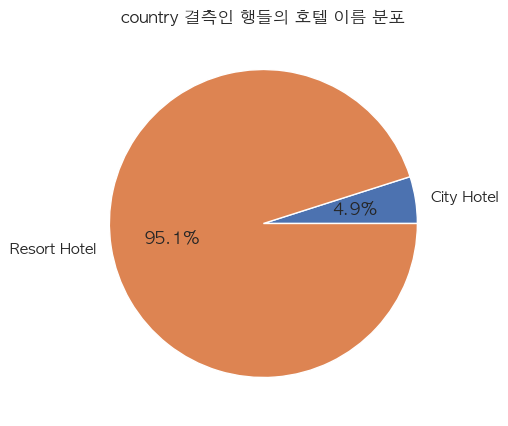

In [215]:
# country 결측치 대치 분석

# - country 결측 행 중 취소된 예약의 비율을 13.7%로, 무시할 수 없다.
# - country가 결측된 행 중 95.1%가 Resort Hotel이다. 
# - 따라서 country 결측은 특정 집단에 몰려있으며, 단순히 결측행을 지워버리거나 임의의 국가 코드를 넣으면 취소 원인 분석에 오류가 생길 수 있다. 
# - 따라서 country 결측 행은 ISO-3166-1을 따라 ZZ로 대치한다.
# - 다만 국가 별 취소율을 확인할 때는 ZZ는 해석 대상에서 제외해야 한다. 

# country 결측 행 중 취소한 예약의 비율
mask_country_nan = full_data['country'].isna()

mask_cancel_country_nan = (full_data['is_canceled'] == 1) & mask_country_nan
cancel_rate_country_nan = len(full_data[mask_cancel_country_nan]) / len(full_data[mask_country_nan])

print(f"country 결측 행 중 취소한 예약의 비율: {round(cancel_rate_country_nan * 100, 1)}%")

# country 결측 행의 호텔 명 분포
hotels_country_nan = full_data[mask_country_nan]['hotel']

f_table_hotels_country_nan = hotels_country_nan.value_counts().sort_index(inplace=False)

f_table_hotels_country_nan.plot.pie(title='country 결측인 행들의 호텔 이름 분포', autopct='%.1f%%', figsize=(5, 5))
plt.show()

In [216]:
# agent 결측치 대치 분석
# market_segment를 살펴보면, Aviation(항공사 관련 예약), Complementary(무료 숙박권), Corporate(법인 고객), 보통 여행사를 거치지 않는 시장 분류에서 agent 결측 비율이 일괄적으로 높다.
# 또한, Online TA, Offline TA/TO는 Agent 결측률이 1%나 0%로, 거의 없다.
# 따라서 agent 결측은 '모르는 값'이 아니라, '여행사가 개입하지 않은 예약'이라고 해석할 수 있다. 
# agent ID에 0이 없음을 set()을 통해 확인했다. 따라서 결측치는 0으로 대치해 '여행사가 개입하지 않은 예약'이라고 해석할 수 있다. 

df_market_segment_with_agent_na_and_cancel_rate= pd.DataFrame(
    {
        'count': full_data['market_segment'].value_counts(), # market_segment 별 도수
        'agent_nan_percentile': full_data.groupby('market_segment')['agent'].apply(lambda x: x.isna().mean()) * 100 ,
        'cancel_percentile': full_data.groupby('market_segment')['is_canceled'].mean() * 100, # market_segment 별 취소율
    }
)

display(df_market_segment_with_agent_na_and_cancel_rate)

# agent ID에 0이 있나?
mask = ~full_data['agent'].isna()

if float(0) in set(full_data[mask]['agent']): 
    print("0이 있습니다.")
else:
    print("0이 없습니다.")

,count,agent_nan_percentile,cancel_percentile
market_segment,,,
Aviation,237,89.451477,21.940928
Complementary,743,86.137281,13.055182
Corporate,5295,86.761095,18.734655
Direct,12606,47.651912,15.341901
Groups,19811,20.937863,61.062036
Offline TA/TO,24219,1.606177,34.316033
Online TA,56477,0.616180,36.721143
Undefined,2,100.000000,100.000000


0이 없습니다.


In [217]:
# company 결측치 대치 분석

# company 컬럼은 '예약을 하였거나 예약금을 지불할 책임이 있는 회사 또는 단체의 ID'를 의미한다. 즉 값이 존재하면 그 예약은 법인이 예약했다고 판단할 수 있다. 
# market segment별로 company 결측률을 확인해보면, Aviation, Corporate에서 결측률이 각각 10%, 15%로, 가장 적다. 그리고 같은 market segement는 agent에 값이 존재한다. 
# 즉, 여행사를 통해 예약한 손님들은 대부분 법인으로 예약했단 것이 된다. 
# 특히, Online TA, Offline TA/TO 에서 agent nan 비율은 각각 0.6%, 1.6%인데 company 결측률은 99.8%, 99.5%를 기록하고 있다. 즉, 여행사가 예약을 대행하면 그 법인이 예약한 것이라고 볼 수 있는 것이다.
# 
# 따라서, company ID에 0이 없으므로, 0으로 결측치를 대치해, 이를 '법인 예약이 아니다'라는 뜻으로 해석할 수 있다. 

# market segment 별 company 결측률
df_market_segment_with_company_na_and_agent_na= pd.DataFrame(
    {
        'company_nan_percentile': full_data.groupby('market_segment')['company'].apply(lambda x: x.isna().mean()) * 100 ,
        'agent_nan_percentile': full_data.groupby('market_segment')['agent'].apply(lambda x: x.isna().mean()) * 100
    }
)
display(df_market_segment_with_company_na_and_agent_na)
display(df_market_segment_with_company_na_and_agent_na.sort_values(by='company_nan_percentile').head(5))

# 호텔 별 company 결측률
df_hotel_with_company_na= pd.DataFrame(
    {
        'company_nan_percentile': full_data.groupby('hotel')['company'].apply(lambda x: x.isna().mean()) * 100 ,
    }
)

display(df_hotel_with_company_na)

# company 결측률: 94.3%
company_nan_percentile = full_data['company'].isna().mean() * 100
print(f"company 결측률: {company_nan_percentile}%")

# company 최빈값: ID: 40 / 빈도: 927
display(full_data['company'].value_counts(sort=True, ascending=False).head(1).reset_index())

# company ID에 0이 있나?
mask = ~full_data['company'].isna()

if float(0.0) in set(full_data[mask]['company']):
    print("0이 있습니다. ")
else:
    print("0이 없습니다. ")

,company_nan_percentile,agent_nan_percentile
market_segment,,
Aviation,10.548523,89.451477
Complementary,57.873486,86.137281
Corporate,15.561851,86.761095
Direct,98.349992,47.651912
Groups,92.978648,20.937863
Offline TA/TO,99.562327,1.606177
Online TA,99.830019,0.616180
Undefined,100.000000,100.000000


,company_nan_percentile,agent_nan_percentile
market_segment,,
Aviation,10.548523,89.451477
Corporate,15.561851,86.761095
Complementary,57.873486,86.137281
Groups,92.978648,20.937863
Direct,98.349992,47.651912


,company_nan_percentile
hotel,
City Hotel,95.349805
Resort Hotel,92.241638


company 결측률: 94.30689337465449%


,company,count
0,40.0,927


0이 없습니다. 


In [218]:
# 결측치 대치하기
nan_replacements = {"children": 0.0, "country": "ZZ", "agent": 0, "company": 0}
full_data_cln = full_data.fillna(nan_replacements)
full_data_cln["children"] = full_data_cln["children"].astype(int) 

In [219]:
# "meal" 컬럼은 "Undefined"와 "SC"가 동일하게 "식사 포함되지 않은 옵션"이라고 했다. 
# 따라서 "Undefined"를 "SC"로 대치해 통일한다.
full_data_cln["meal"].replace("Undefined", "SC")

0         BB
1         BB
2         BB
3         BB
4         BB
          ..
119385    BB
119386    BB
119387    BB
119388    BB
119389    HB
Name: meal, Length: 119390, dtype: str

In [220]:
if len(get_nan_df(full_data_cln)) == 0:
    print("Nan값이 모두 처리되었습니다.")
else:
    print("Nan값이 아직 남아있습니다.")
    display(get_nan_df(full_data_cln))

Nan값이 모두 처리되었습니다.


## 2. 논리적으로 말이 되지 않는 경우 대처하기

| 규칙 | 조건 |
|---|---|
| 투숙객 0명 | `adults + children + babies == 0` |
| 체크아웃일 불일치 | `Check-Out`인데 `reservation_status_date != 도착일 + 숙박일수` |
| 노쇼 상태일 불일치 | `No-Show`인데 `reservation_status_date != 도착일` |
| 성인 없이 투숙한 아기 | `babies > 0 and adults == 0` |
| 재방문 플래그 모순 | `is_repeated_guest == 0`인데 `previous_bookings_not_canceled > 0` |
| 극단값 | `adults`, `babies`, `children` 이상치 |
| 예약 일수가 예약~도착 기간을 넘음 | `lead_time < days_in_waiting_list` 
| 상태 변경일이 예약일보다 앞섬 | `도착일 - lead_time > reservation_status_date` |
| 취소했는데 상태 확정일이 도착일보다 늦음 | `reservation_status == Canceled` & `reservation_status_date > 도착일` | 
| 존재하지 않는 날짜 | ex_ 2월 30일 | 

In [221]:
# 규칙 검증에 필요한 파생 컬럼을 먼저 만들어 둔다.
# - arrival_date           : 도착 연/월/일을 합친 날짜. errors='coerce'로 파싱하므로 2월 30일 같은 없는 날짜는 NaT가 된다.
# - status_date            : reservation_status_date를 날짜 타입으로 변환한 값
# - total_nights           : 주말 숙박일 + 주중 숙박일
# - expected_checkout_date : 도착일 + 총 숙박일수. Check-Out으로 끝난 예약이면 상태 확정일이 이 날짜여야 한다.
# - booking_date           : 도착일 - lead_time. 실제로 예약을 넣은 시점이다.
#
# 원본을 건드리지 않기 위해 검증용 사본 df_chk를 쓰고, 규칙별 위반 마스크는 error_masks에 모아 마지막에 한 번에 요약한다.

df_chk = full_data_cln.copy()


arrival_str = (
    df_chk['arrival_date_year'].astype(str) + '-'
    + df_chk['arrival_date_month'] + '-'
    + df_chk['arrival_date_day_of_month'].astype(str)
) # Series


df_chk['arrival_date'] = pd.to_datetime(arrival_str, format='%Y-%B-%d', errors='coerce') # Pandas.Timestamp
df_chk['status_date'] = pd.to_datetime(df_chk['reservation_status_date'], format='%Y-%m-%d', errors='coerce') # Pandas.Timestamp
df_chk['total_nights'] = df_chk['stays_in_weekend_nights'] + df_chk['stays_in_week_nights'] # np.int64
df_chk['expected_checkout_date'] = df_chk['arrival_date'] + pd.to_timedelta(df_chk['total_nights'], unit='D') # pandas.Timestamp
df_chk['booking_date'] = df_chk['arrival_date'] - pd.to_timedelta(df_chk['lead_time'], unit='D') # pandas.Timestamp


error_masks = {}  # 규칙명 -> 위반 여부 마스크

COLOR_OK = '#2a78d6'    # 정상
COLOR_BAD = '#d03b3b'   # 위반
COLOR_INK = '#52514e'   # 값 라벨
COLOR_GRID = '#e1e0d9'  # 격자


def report(rule, mask, cols=None, n=5):
    """규칙 위반 마스크를 등록하고 건수/비율과 샘플 행을 출력한다."""
    error_masks[rule] = mask
    n_err = int(mask.sum())
    print(f"[{rule}] 위반 {n_err:,}건 / 전체 {len(mask):,}건 ({n_err / len(mask) * 100:.3f}%)")
    if n_err and cols:
        display(df_chk.loc[mask, cols].head(n))


def plot_counts(counts, title, color=COLOR_BAD, xlabel='건수', fmt='%d'):
    """value_counts 형태의 Series를 값 라벨이 붙은 가로 막대로 그린다."""
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(counts) + 1.4))
    bars = ax.barh(counts.index.astype(str), counts.values, color=color, height=0.62)
    ax.bar_label(bars, fmt=fmt, padding=4, color=COLOR_INK)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, counts.max() * 1.18)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    plt.show()


display(df_chk[['arrival_date', 'total_nights', 'expected_checkout_date', 'booking_date', 'status_date']].head(5))

for col in ['arrival_date', 'total_nights', 'expected_checkout_date', 'booking_date', 'status_date']:
    print(f"type of {col}: {df_chk[col].dtype}")

,arrival_date,total_nights,expected_checkout_date,booking_date,status_date
0,2015-07-01,0,2015-07-01,2014-07-24,2015-07-01
1,2015-07-01,0,2015-07-01,2013-06-24,2015-07-01
2,2015-07-01,1,2015-07-02,2015-06-24,2015-07-02
3,2015-07-01,1,2015-07-02,2015-06-18,2015-07-02
4,2015-07-01,2,2015-07-03,2015-06-17,2015-07-03


type of arrival_date: datetime64[us]
type of total_nights: int64
type of expected_checkout_date: datetime64[us]
type of booking_date: datetime64[us]
type of status_date: datetime64[us]


[투숙객 0명] 위반 180건 / 전체 119,390건 (0.151%)


,hotel,adults,children,babies,total_nights,reservation_status
2224,Resort Hotel,0,0,0,3,Check-Out
2409,Resort Hotel,0,0,0,0,Check-Out
3181,Resort Hotel,0,0,0,3,Check-Out
3684,Resort Hotel,0,0,0,5,Check-Out
3708,Resort Hotel,0,0,0,6,Check-Out


이 중 숙박일수까지 0인 건: 70건


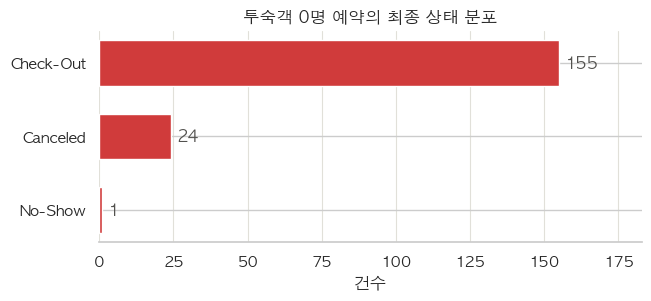

In [222]:
# [규칙 1] 투숙객 0명: adults + children + babies == 0
# 사람이 한 명도 없는 예약은 성립할 수 없다.
# 단순 입력 실수라면 취소로 끝났을 텐데, 180건 중 155건이 Check-Out(체크인 후 체크아웃 처리)으로 남아 있다.
# 즉 '아무도 묵지 않았는데 숙박이 끝난' 기록이라 이 행들의 인원 정보는 신뢰할 수 없다.

mask_no_guest = (df_chk['adults'] + df_chk['children'] + df_chk['babies']) == 0

report('투숙객 0명', mask_no_guest,
       ['hotel', 'adults', 'children', 'babies', 'total_nights', 'reservation_status'])

print(f"이 중 숙박일수까지 0인 건: {int((df_chk.loc[mask_no_guest, 'total_nights'] == 0).sum())}건")

plot_counts(df_chk.loc[mask_no_guest, 'reservation_status'].value_counts(),
            '투숙객 0명 예약의 최종 상태 분포')

[체크아웃일 불일치] 위반 27건 / 전체 119,390건 (0.023%)


,hotel,distribution_channel,arrival_date,total_nights,expected_checkout_date,status_date
24,Resort Hotel,TA/TO,2015-07-01,7,2015-07-08,2015-07-01
313,Resort Hotel,TA/TO,2015-07-12,7,2015-07-19,2015-07-12
803,Resort Hotel,TA/TO,2015-07-30,3,2015-08-02,2015-07-30
1657,Resort Hotel,TA/TO,2015-09-07,10,2015-09-17,2015-09-07
2224,Resort Hotel,Corporate,2015-10-06,3,2015-10-09,2015-10-06
2345,Resort Hotel,TA/TO,2015-10-09,7,2015-10-16,2015-10-09
2407,Resort Hotel,Corporate,2015-10-11,9,2015-10-20,2015-10-11
2420,Resort Hotel,Direct,2015-10-12,7,2015-10-19,2015-10-12
5957,Resort Hotel,TA/TO,2016-05-17,8,2016-05-25,2016-05-17
6755,Resort Hotel,TA/TO,2016-06-29,14,2016-07-13,2016-06-29


상태 확정일 == 도착일 (0박으로 기록): 26건
기록된 숙박일수가 예약보다 짧은 건: 27건


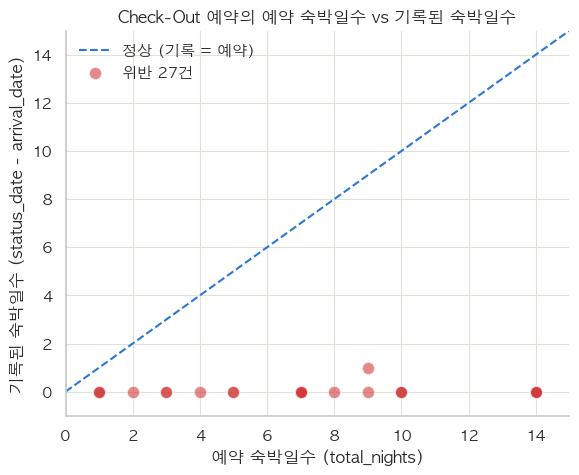

In [223]:
# [규칙 2] 체크아웃일 불일치: reservation_status == 'Check-Out' 인데 status_date != 도착일 + 숙박일수
# 체크아웃으로 끝난 예약이라면 상태 확정일은 체크아웃 예정일과 같아야 한다.
# 위반 27건은 모두 기록된 숙박일수가 예약 숙박일수보다 짧고, 그중 26건은 상태 확정일이 도착일과 같다(= 0박으로 기록).
# 도착일에 상태가 확정됐는데 Check-Out으로 남은 것이므로, 상태값과 날짜 중 하나는 잘못된 값이다.

mask_checkout_date = (
    (df_chk['reservation_status'] == 'Check-Out')
    & (df_chk['status_date'] != df_chk['expected_checkout_date'])
)

report('체크아웃일 불일치', mask_checkout_date,
       ['hotel', 'distribution_channel', 'arrival_date', 'total_nights', 'expected_checkout_date', 'status_date'],
       n = None)

recorded_nights = (df_chk.loc[mask_checkout_date, 'status_date'] - df_chk.loc[mask_checkout_date, 'arrival_date']).dt.days
booked_nights = df_chk.loc[mask_checkout_date, 'total_nights']

print(f"상태 확정일 == 도착일 (0박으로 기록): {int((recorded_nights == 0).sum())}건")
print(f"기록된 숙박일수가 예약보다 짧은 건: {int((recorded_nights < booked_nights).sum())}건")

fig, ax = plt.subplots(figsize=(6.5, 5))
lim = booked_nights.max() + 1
ax.plot([0, lim], [0, lim], linestyle='--', color=COLOR_OK, linewidth=1.5, label='정상 (기록 = 예약)')
ax.scatter(booked_nights, recorded_nights, s=80, color=COLOR_BAD, alpha=0.6,
           edgecolor='white', linewidth=1, zorder=3, label=f'위반 {len(booked_nights)}건')
ax.set_xlabel('예약 숙박일수 (total_nights)')
ax.set_ylabel('기록된 숙박일수 (status_date - arrival_date)')
ax.set_title('Check-Out 예약의 예약 숙박일수 vs 기록된 숙박일수')
ax.set_xlim(0, lim)
ax.set_ylim(-1, lim)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color=COLOR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

In [224]:
# [규칙 3] 노쇼 상태일 불일치: reservation_status == 'No-Show' 인데 status_date != arrival_date
# "노쇼"라는 사실은 정의상 도착 예정일이 지나야 확정될 수 있는데, 이 규칙에 걸린다면 도착 예정일이 오기도 전에 노쇼 상태로 확정되었다는 것을 의미힌다. 
# 위반은 1건뿐이고, 도착일보다 111일이나 앞서 노쇼로 확정돼 있다. 실제로는 취소 건이 노쇼로 잘못 기록된 것으로 보인다.

mask_noshow_date = (
    (df_chk['reservation_status'] == 'No-Show')
    & (df_chk['status_date'] != df_chk['arrival_date'])
)

report('노쇼 상태일 불일치', mask_noshow_date,
       ['hotel', 'arrival_date', 'status_date', 'lead_time', 'market_segment'])

gap = (df_chk.loc[mask_noshow_date, 'status_date'] - df_chk.loc[mask_noshow_date, 'arrival_date']).dt.days
print(f"도착일 대비 상태 확정일 차이(일): {gap.tolist()}")
print(f"정상(차이 0일)인 No-Show: {int(((df_chk['reservation_status'] == 'No-Show') & ~mask_noshow_date).sum()):,}건")

[노쇼 상태일 불일치] 위반 1건 / 전체 119,390건 (0.001%)


,hotel,arrival_date,status_date,lead_time,market_segment
7035,Resort Hotel,2016-07-17,2016-03-28,181,Online TA


도착일 대비 상태 확정일 차이(일): [-111]
정상(차이 0일)인 No-Show: 1,206건


성인 없이 투숙한 아기: 3건
[성인 없이 투숙한 아기/어린이] 위반 3건 / 전체 119,390건 (0.003%)


,hotel,adults,children,babies,total_nights,reservation_status
46150,City Hotel,0,2,1,1,Check-Out
81375,City Hotel,0,2,1,5,No-Show
90790,City Hotel,0,2,1,3,Check-Out


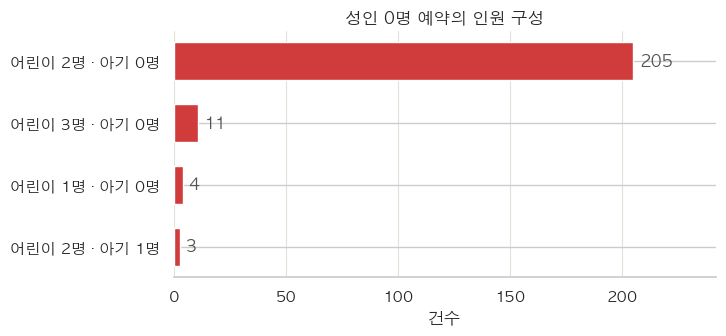

In [225]:
# [규칙 4] 성인 없이 투숙한 아기: babies > 0 & adults == 0
# 아기 혼자 투숙할 수는 없다. 같은 이유로 어린이만 있고 성인이 없는 예약도 성립하지 않으므로 범위를 넓혀서 함께 본다.
# 아기 기준으로는 3건뿐이지만, 성인 0명 + 미성년자만 있는 예약은 223건이다.
# 하지만 해당 호텔이 속한 국가의 법을 현재 알 수없고, children과 baby의 연령 기준이 명시되어있지 않다.
# 따라서 보수적으로 성인 없이 투숙한 아기만 필터링하고, 성인 없이 투숙한 미성년자는 제거하지 않는다. 

mask_baby_no_adult = (df_chk['babies'] > 0) & (df_chk['adults'] == 0)
mask_minor_no_adult = (df_chk['adults'] == 0) & ((df_chk['babies'] > 0) | (df_chk['children'] > 0))

print(f"성인 없이 투숙한 아기: {int(mask_baby_no_adult.sum())}건")

report('성인 없이 투숙한 아기/어린이', mask_baby_no_adult,
       ['hotel', 'adults', 'children', 'babies', 'total_nights', 'reservation_status'])

combo = df_chk.loc[mask_minor_no_adult].groupby(['children', 'babies']).size().sort_values(ascending=False)
combo.index = [f'어린이 {c}명 · 아기 {b}명' for c, b in combo.index]

plot_counts(combo, '성인 0명 예약의 인원 구성')

[재방문 플래그 모순] 위반 782건 / 전체 119,390건 (0.655%)


,is_repeated_guest,previous_bookings_not_canceled,previous_cancellations,is_canceled
13803,0,1,0,0
13804,0,2,0,0
13805,0,3,1,1
13808,0,1,0,0
13811,0,1,1,1


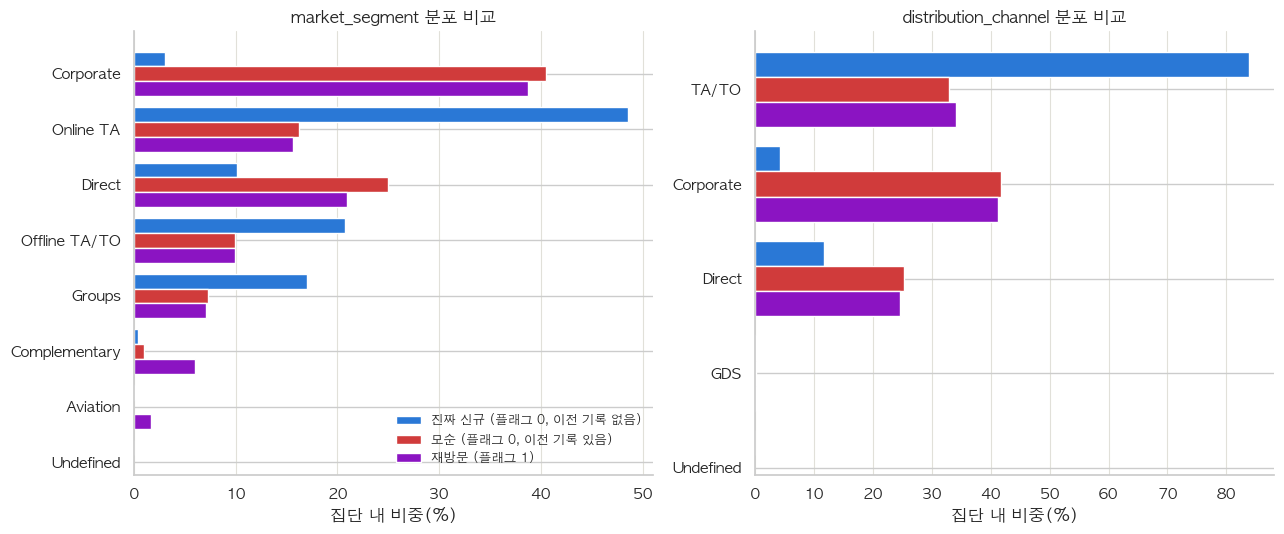

In [226]:
# [규칙 5] 재방문 플래그 모순: is_repeated_guest == 0 인데 previous_bookings_not_canceled > 0
# 취소하지 않은 이전 예약이 있다는 것은 이미 방문한 적이 있다는 뜻이므로 재방문 고객이어야 한다.
# 그렇다면 이 모순 집단은 크기가 얼마나 될까? 782건으로, 전체의 0.655%이다. 
# 이 모순 집단을 어떻게 처리해야 할까? 이 모순 집단 행을 빼야할까? 값을 바꿔 넣어야 할까?
# 값을 바꿔넣는다면 어떤 값으로 바꿔넣어야 할까? 

# 1. 행을 지운다 VS 다른 값으로 대치한다
#   - previous_bookings_not_canceled > 0이라는 값 자체가 "취소하지 않고 완료된 과거 예약이 존재한다"는 관측된 사실이고, 
#   - 이게 참이면 is_repeated_guest = 1이라는 결론은 추정이 아니라 논리적 필연이다. 따라서 행을 지우는 것은 맞지 않다.

# 2. 그러면 is_repeated_guest 컬럼이 틀렸을까, previous_bookings_not_canceled 컬럼이 틀렸을까?
#   - is_repeated_guest가 틀렸다고 판단하면 값은 자동으로 1이 되고, 반대로 previous_bookings_not_canceled가 틀렸다고 판단하면 값은 0이 된다. 
#   - 판단의 기준: 
#       - 두 필드가 시스템에서 만들어지는 과정을 생각해보자. previous_bookings_not_canceled가 0보다 크다는 건 고객 식별이 이미 프론트 데스크에 얼굴을 비치고 행정작업을 했다는 뜻이다. 
#       - 식별이 성공했는데 is_repeated_guest 플래그만 0으로 남았다면, 이건 별도의 플래그 생성 단계에서 갱신이 누락된 버그일 수 있다. 
#       - 반대로 '식별은 성공했는데 집계 카운트는 오르지 않았다'는 시나리오는 상대적으로 설명이 덜 매끄럽다. 

#   -> 따라서 둘 중 틀렸다고 가정할 수 있는 값은 is_repeated_guest이고, 모순 집단에 대해 is_repeated_guest = 1로 대치하는 게 타당하다. 

# 3. 그렇다면 모순 집단은 진짜 재방문 집단과 비슷한 분포를 보일까?
#   - 이에 대해서 판단하기 위해서 여러 변수들을 세 집단 간에 비교해 모순 집단이 진짜 신규 집단과 재방문 집단 둘 중 어느 집단과 더 유사한 지 확인할 수 있다. 
#   - market_segment/distribution_channel 분포에서 모순 집단은 재방문 집단과 거의 겹치고, 진짜 신규 집단과는 뚜렷이 다르다.
#   - 따라서 모순 집단을 재방문 집단이라고 가정하는 게 타당하다. 

mask_repeat_conflict = (df_chk['is_repeated_guest'] == 0) & (df_chk['previous_bookings_not_canceled'] > 0)

report('재방문 플래그 모순', mask_repeat_conflict,
       ['is_repeated_guest', 'previous_bookings_not_canceled', 'previous_cancellations', 'is_canceled'])

groups = {
    '진짜 신규 (플래그 0, 이전 기록 없음)': (df_chk['is_repeated_guest'] == 0) & (df_chk['previous_bookings_not_canceled'] == 0),
    '모순 (플래그 0, 이전 기록 있음)': mask_repeat_conflict,
    '재방문 (플래그 1)': df_chk['is_repeated_guest'] == 1,
}

GROUP_COLORS = [COLOR_OK, COLOR_BAD,"#8b14c2"]  # [진짜 신규 / 모순 / 재방문]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, col in zip(axes, ['market_segment', 'distribution_channel']):
    dist = pd.DataFrame({
        name: df_chk.loc[m, col].value_counts(normalize=True) * 100 # normalize: 도수 대신 상대도수(비율)로 반환.
        for name, m in groups.items()
    })
    dist = dist.loc[dist.mean(axis=1).sort_values(ascending=False).index]  # 평균 비중이 큰 카테고리부터 정렬

    n_cat = len(dist)   # market_segment, distribution_channel의 카테고리 개수
    n_grp = len(groups) # 3개 [진짜 신규 / 모순 / 재방문]
    bar_h = 0.8 / n_grp
    y = list(range(n_cat))

    for i, (name, color) in enumerate(zip(groups, GROUP_COLORS)):
        offset = (i - (n_grp - 1) / 2) * bar_h
        ax.barh([yy + offset for yy in y], dist[name], height=bar_h, color=color, label=name)

    ax.set_yticks(y)
    ax.set_yticklabels(dist.index)
    ax.invert_yaxis()
    ax.set_title(f'{col} 분포 비교')
    ax.set_xlabel('집단 내 비중(%)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8)
    ax.set_axisbelow(True)

axes[0].legend(frameon=False, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

,q1,q3,iqr,iqr_fence,over_iqr_fence_freq,over_iqr_fence_perc
adults,2.0,2.0,0.0,2.0,6280.0,5.26
children,0.0,0.0,0.0,0.0,8590.0,7.19
babies,0.0,0.0,0.0,0.0,917.0,0.77


iqr 임계치를 넘기는 행 수:  15073 , 그리고 그 퍼센티지:  12.63


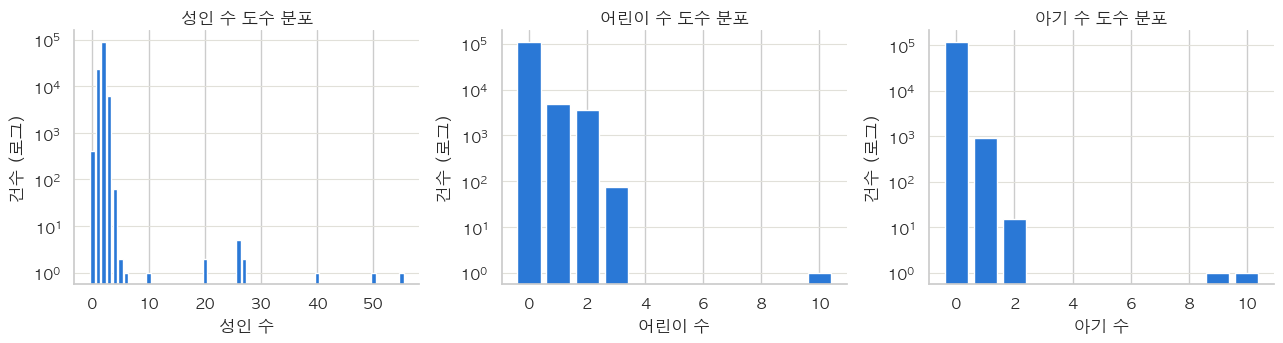

즉, IQR만을 기반으로 이상치를 판단하면, 전체의 12.63%를 날려버리는 셈이 된다. 그 이유는 각 컬럼의 분포가 0~3 사이에 뭉쳐있기 때문이다.
따라서 IQR 기반 외에 다른 기준이 필요하다.
성인 10 / 어린이 5 / 아기 5 을 이상치 임계값으로 설정하고 다시 살펴본다. 
성인: IQR 위반 6,280건 중 적용 임계값 이내 6,268건(99.8%), 임계값 초과(진짜 극단값) 12건(0.2%)
어린이: IQR 위반 8,590건 중 적용 임계값 이내 8,589건(100.0%), 임계값 초과(진짜 극단값) 1건(0.0%)
아기: IQR 위반 917건 중 적용 임계값 이내 915건(99.8%), 임계값 초과(진짜 극단값) 2건(0.2%)


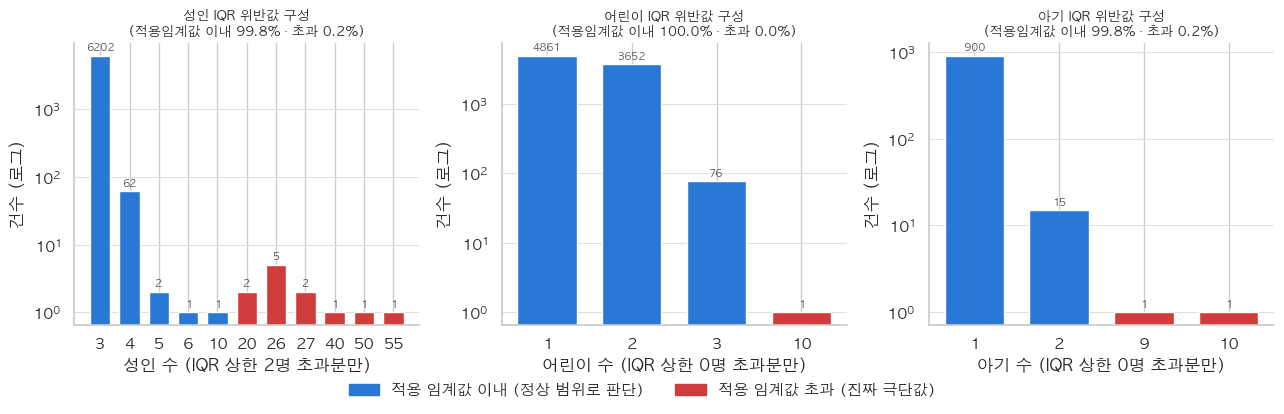

[인원 극단값] 위반 15건 / 전체 119,390건 (0.013%)


,hotel,adults,children,babies,market_segment,reservation_status
328,Resort Hotel,2,10,0,Offline TA/TO,No-Show
1539,Resort Hotel,40,0,0,Direct,Canceled
1587,Resort Hotel,26,0,0,Offline TA/TO,Canceled
1643,Resort Hotel,50,0,0,Direct,Canceled
1752,Resort Hotel,26,0,0,Offline TA/TO,Canceled
1884,Resort Hotel,26,0,0,Offline TA/TO,Canceled
1917,Resort Hotel,27,0,0,Direct,Canceled
1962,Resort Hotel,27,0,0,Direct,Canceled
2003,Resort Hotel,26,0,0,Offline TA/TO,Canceled
2164,Resort Hotel,26,0,0,Offline TA/TO,Canceled


In [227]:
# [[규칙 6] 극단값: 예약 인수의 극단적인 값을 파악하고, 이상치를 제거한다. 

# 우선 IQR 기반으로 이상치 임계값을 산정한다. 
tmp = df_chk[['adults', 'children', 'babies']].quantile([0.25, 0.75]).transpose()
tmp.columns = ['q1', 'q3']
tmp['iqr'] = tmp['q3'] - tmp['q1']
tmp['iqr_fence'] = tmp['q3'] + 1.5 * tmp['iqr']
tmp.loc['adults','over_iqr_fence_freq'] = int(len(df_chk[df_chk['adults'] > tmp.loc['adults', 'iqr_fence']]))
tmp.loc['children','over_iqr_fence_freq'] = int(len(df_chk[df_chk['children'] > tmp.loc['children', 'iqr_fence']]))
tmp.loc['babies','over_iqr_fence_freq'] = int(len(df_chk[df_chk['babies'] > tmp.loc['babies', 'iqr_fence']]))
tmp.loc['adults', 'over_iqr_fence_perc'] = round(tmp.loc['adults','over_iqr_fence_freq'] / len(df_chk['adults']) * 100, 2)
tmp.loc['children', 'over_iqr_fence_perc'] = round(tmp.loc['children','over_iqr_fence_freq'] / len(df_chk['children']) * 100, 2)
tmp.loc['babies', 'over_iqr_fence_perc'] = round(tmp.loc['babies','over_iqr_fence_freq'] / len(df_chk['babies']) * 100, 2)

display(tmp)

mask_over_iqr_fence = (df_chk['adults'] > tmp.loc['adults', 'iqr_fence']) | (df_chk['children'] > tmp.loc['children', 'iqr_fence']) | (df_chk['babies'] > tmp.loc['babies', 'iqr_fence'])
print("iqr 임계치를 넘기는 행 수: ", len(df_chk[mask_over_iqr_fence]), ", 그리고 그 퍼센티지: ", round(len(df_chk[mask_over_iqr_fence]) / len(df_chk)*100, 2))

# 도수 분포를 시각적으로 확인한다. 
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (col, name) in zip(axes, [('adults', '성인'), ('children', '어린이'), ('babies', '아기')]):
    counts = df_chk[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, width=0.8, color=COLOR_OK)
    ax.set_yscale('log')
    ax.set_title(f'{name} 수 도수 분포')
    ax.set_xlabel(f'{name} 수')
    ax.set_ylabel('건수 (로그)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("즉, IQR만을 기반으로 이상치를 판단하면, 전체의 12.63%를 날려버리는 셈이 된다. 그 이유는 각 컬럼의 분포가 0~3 사이에 뭉쳐있기 때문이다.")
print("따라서 IQR 기반 외에 다른 기준이 필요하다.")
print("성인 10 / 어린이 5 / 아기 5 을 이상치 임계값으로 설정하고 다시 살펴본다. ")

# 그래서 IQR 위반 값들만 따로 떼어내 실제 적용 임계값(성인 10 / 어린이 5 / 아기 5) 기준으로 색을 나눠 그 구성을 확인한다.

import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
for ax, (col, name, threshold) in zip(axes, [('adults', '성인', 10), ('children', '어린이', 5), ('babies', '아기', 5)]):
    fence = tmp.loc[col, 'iqr_fence']
    viol = df_chk.loc[df_chk[col] > fence, col]
    counts = viol.value_counts().sort_index()
    colors = [COLOR_OK if v <= threshold else COLOR_BAD for v in counts.index]
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.7)
    ax.bar_label(bars, fmt='%d', padding=2, fontsize=7.5, color=COLOR_INK)
    ax.set_yscale('log')

    n_plausible = int((viol <= threshold).sum())
    n_total = len(viol)
    pct_plausible = n_plausible / n_total * 100
    ax.set_title(f'{name} IQR 위반값 구성\n(적용임계값 이내 {pct_plausible:.1f}% · 초과 {100 - pct_plausible:.1f}%)', fontsize=9.5)
    ax.set_xlabel(f'{name} 수 (IQR 상한 {fence:g}명 초과분만)')
    ax.set_ylabel('건수 (로그)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    print(f"{name}: IQR 위반 {n_total:,}건 중 적용 임계값 이내 {n_plausible:,}건({pct_plausible:.1f}%), "
          f"임계값 초과(진짜 극단값) {n_total - n_plausible:,}건({100 - pct_plausible:.1f}%)")

legend_handles = [
    mpatches.Patch(color=COLOR_OK, label='적용 임계값 이내 (정상 범위로 판단)'),
    mpatches.Patch(color=COLOR_BAD, label='적용 임계값 초과 (진짜 극단값)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# 즉 IQR 규칙이 잡아낸 위반 건수의 99% 이상은 성인 3~10명, 어린이 1~3명, 아기 1~2명처럼 실제로는
# 흔히 있을 수 있는 값이고, 그중에서도 정말 비현실적인 값(성인 20명 이상, 어린이 10명, 아기 9~10명)은
# 극소수(성인 12건 · 어린이 1건 · 아기 2건)뿐이다. 따라서 IQR 상한을 그대로 이상치 기준으로 쓰면
# 정상 예약을 대량으로 오탐하게 되고, 지금처럼 적용 임계값(10/5/5)을 기준으로 삼는 것이 타당하다.

mask_extreme = (df_chk['adults'] > 10) | (df_chk['children'] > 5) | (df_chk['babies'] > 5)

report('인원 극단값', mask_extreme,
       ['hotel', 'adults', 'children', 'babies', 'market_segment', 'reservation_status'], n=15)

[대기일수가 리드타임 초과] 위반 0건 / 전체 119,390건 (0.000%)
대기일수 > 0 인 예약: 3,698건 · (lead_time - days_in_waiting_list) 최솟값: 0일


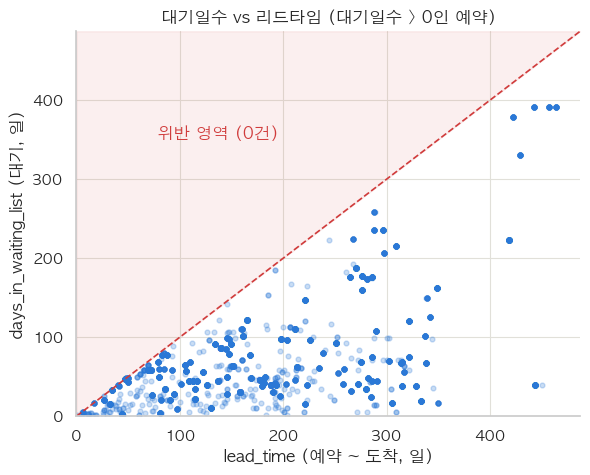

In [228]:
# [규칙 7] 예약 대기일수가 예약~도착 기간을 넘음: lead_time < days_in_waiting_list
# 대기자 명단에 있던 기간은 예약 시점과 도착 시점 사이에 들어가야 하므로 lead_time을 넘을 수 없다.
# 위반은 0건이고, 대기일수가 0보다 큰 3,698건에서도 (lead_time - days_in_waiting_list)의 최솟값이 0일이다.
# 즉 두 컬럼의 관계는 논리적으로 일관된다. 보정할 게 없다. 

mask_wait_over_lead = df_chk['lead_time'] < df_chk['days_in_waiting_list']

report('대기일수가 리드타임 초과', mask_wait_over_lead,
       ['lead_time', 'days_in_waiting_list', 'market_segment'])

df_waiting = df_chk[df_chk['days_in_waiting_list'] > 0]
print(f"대기일수 > 0 인 예약: {len(df_waiting):,}건 "
      f"· (lead_time - days_in_waiting_list) 최솟값: {int((df_waiting['lead_time'] - df_waiting['days_in_waiting_list']).min())}일")

fig, ax = plt.subplots(figsize=(6.5, 5))
lim = max(df_waiting['lead_time'].max(), df_waiting['days_in_waiting_list'].max()) * 1.05
ax.fill_between([0, lim], [0, lim], [lim, lim], color=COLOR_BAD, alpha=0.08)  # 위반 영역
ax.plot([0, lim], [0, lim], linestyle='--', color=COLOR_BAD, linewidth=1.2)
ax.scatter(df_waiting['lead_time'], df_waiting['days_in_waiting_list'], s=12, alpha=0.25, color=COLOR_OK)
ax.text(lim * 0.16, lim * 0.72, '위반 영역 (0건)', color=COLOR_BAD)
ax.set_xlabel('lead_time (예약 ~ 도착, 일)')
ax.set_ylabel('days_in_waiting_list (대기, 일)')
ax.set_title('대기일수 vs 리드타임 (대기일수 > 0인 예약)')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color=COLOR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

[상태 확정일이 예약일 이전] 위반 0건 / 전체 119,390건 (0.000%)
예약 ~ 상태 확정까지 걸린 일수 | 최소 0일 · 중앙값 39.0일 · 최대 737일


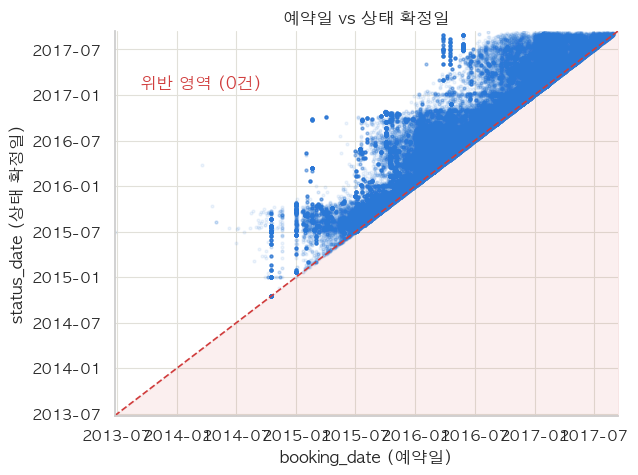

In [229]:
# [규칙 8] 상태 변경일이 예약일보다 앞섬: status_date < booking_date (= 도착일 - lead_time)
# 예약을 넣기도 전에 예약 상태가 확정될 수는 없다.
# 위반은 0건이고, 예약 시점부터 상태 확정까지 걸린 일수의 최솟값도 0일이라 시간 순서가 어긋나는 행은 없다.

mask_status_before_booking = df_chk['status_date'] < df_chk['booking_date']

report('상태 확정일이 예약일 이전', mask_status_before_booking,
       ['booking_date', 'arrival_date', 'status_date', 'lead_time'])

days_to_status = (df_chk['status_date'] - df_chk['booking_date']).dt.days
print(f"예약 ~ 상태 확정까지 걸린 일수 | 최소 {days_to_status.min()}일 "
      f"· 중앙값 {days_to_status.median()}일 · 최대 {days_to_status.max()}일")

fig, ax = plt.subplots(figsize=(6.5, 5))
lo = min(df_chk['booking_date'].min(), df_chk['status_date'].min())
hi = max(df_chk['booking_date'].max(), df_chk['status_date'].max())
ax.fill_between([lo, hi], [lo, lo], [lo, hi], color=COLOR_BAD, alpha=0.08)  # 위반 영역 (대각선 아래 = 상태 확정일 < 예약일)
ax.plot([lo, hi], [lo, hi], linestyle='--', color=COLOR_BAD, linewidth=1.2, label='정상 경계 (상태 확정일 = 예약일)')
ax.scatter(df_chk['booking_date'], df_chk['status_date'], s=4, alpha=0.08, color=COLOR_OK)
ax.text(lo + (hi - lo) * 0.05, lo + (hi - lo) * 0.85, '위반 영역 (0건)', color=COLOR_BAD)
ax.set_xlabel('booking_date (예약일)')
ax.set_ylabel('status_date (상태 확정일)')
ax.set_title('예약일 vs 상태 확정일')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color=COLOR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

[취소 확정일이 도착일 이후] 위반 0건 / 전체 119,390건 (0.000%)
도착 당일 취소: 881건 · 최소 0일 전 · 중앙값 56.0일 전


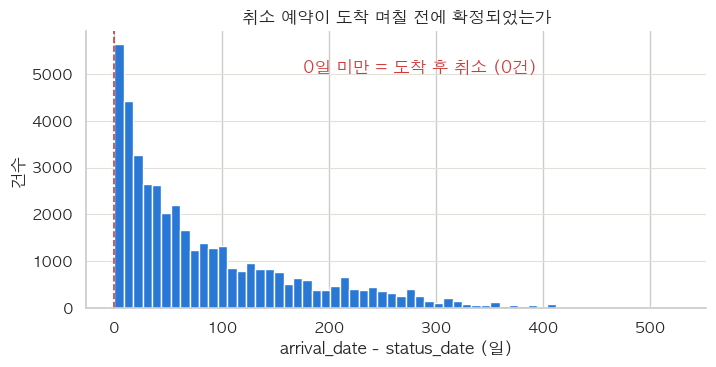

In [230]:
# [규칙 9] 취소했는데 상태 확정일이 도착일보다 늦음: reservation_status == 'Canceled' & status_date > 도착일
# 도착일이 지난 뒤에는 취소가 아니라 노쇼나 체크아웃으로 처리돼야 한다.
# 위반은 0건이다. 취소는 도착 당일(881건)이 가장 늦고, 중앙값은 도착 56일 전이다.

mask_canceled = df_chk['reservation_status'] == 'Canceled'
mask_cancel_after_arrival = mask_canceled & (df_chk['status_date'] > df_chk['arrival_date'])

report('취소 확정일이 도착일 이후', mask_cancel_after_arrival,
       ['arrival_date', 'status_date', 'lead_time'])

days_before_arrival = (df_chk.loc[mask_canceled, 'arrival_date'] - df_chk.loc[mask_canceled, 'status_date']).dt.days
print(f"도착 당일 취소: {int((days_before_arrival == 0).sum()):,}건 "
      f"· 최소 {days_before_arrival.min()}일 전 · 중앙값 {days_before_arrival.median()}일 전")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(days_before_arrival, bins=60, color=COLOR_OK)
ax.axvline(0, color=COLOR_BAD, linestyle='--', linewidth=1.2)
ax.text(0.35, 0.85, '0일 미만 = 도착 후 취소 (0건)', color=COLOR_BAD, transform=ax.transAxes)
ax.set_xlabel('arrival_date - status_date (일)')
ax.set_ylabel('건수')
ax.set_title('취소 예약이 도착 며칠 전에 확정되었는가')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

In [231]:
# [규칙 10] 존재하지 않는 날짜: 2월 30일처럼 달력에 없는 날짜
# 파생 컬럼을 만들 때 errors='coerce'로 파싱했으므로, 없는 날짜라면 arrival_date가 NaT로 남는다.
# 위반은 0건이다. 따라서 앞의 날짜 규칙들도 NaT 때문에 잘못 잡힌 게 아니라는 것까지 함께 확인된 셈이다.
# 월별 도착일 최댓값도 그 달의 마지막 날을 넘지 않는다. (2월은 윤년인 2016년이 있어 29일까지 정상)

mask_invalid_date = df_chk['arrival_date'].isna() | df_chk['status_date'].isna()

report('존재하지 않는 날짜', mask_invalid_date,
       ['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'reservation_status_date'])

last_day_of_month = {
    'January': 31, 'February': 29, 'March': 31, 'April': 30, 'May': 31, 'June': 30,
    'July': 31, 'August': 31, 'September': 30, 'October': 31, 'November': 30, 'December': 31,
}

df_month_check = pd.DataFrame({
    '최대 도착일': df_chk.groupby('arrival_date_month')['arrival_date_day_of_month'].max(),
    '월 마지막 날': pd.Series(last_day_of_month),
}).loc[list(last_day_of_month)]
df_month_check['정상'] = df_month_check['최대 도착일'] <= df_month_check['월 마지막 날']

display(df_month_check)

[존재하지 않는 날짜] 위반 0건 / 전체 119,390건 (0.000%)


,최대 도착일,월 마지막 날,정상
January,31,31,True
February,29,29,True
March,31,31,True
April,30,30,True
May,31,31,True
June,30,30,True
July,31,31,True
August,31,31,True
September,30,30,True
October,31,31,True


,위반 건수,전체 대비 비율(%)
재방문 플래그 모순,782,0.655
투숙객 0명,180,0.151
체크아웃일 불일치,27,0.023
인원 극단값,15,0.013
성인 없이 투숙한 아기/어린이,3,0.003
노쇼 상태일 불일치,1,0.001
대기일수가 리드타임 초과,0,0.000
상태 확정일이 예약일 이전,0,0.000
취소 확정일이 도착일 이후,0,0.000
존재하지 않는 날짜,0,0.000


규칙을 하나라도 위반한 행: 1,005건 (0.84%)


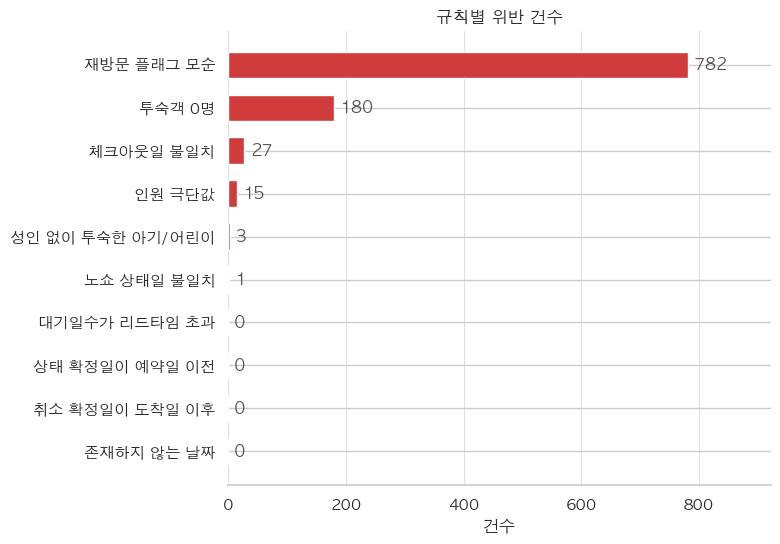

제외한 행: 225건 · 남은 행: 119,165건 (99.81%)
재방문 플래그 보정: 782건 -> is_repeated_guest = 1


In [232]:
# [요약] 규칙별 위반 건수와 처리 방침
# 논리적으로 불가능한 행은 전체의 1.03%(1,225건)뿐이라, 제외하든 보정하든 전체 취소율 분석의 결론은 바뀌지 않는다.
# 다만 성격이 다르므로 두 갈래로 나눠 처리한다.
#   - 값 자체를 못 믿는 경우(투숙객 0명 / 성인 없이 투숙한 아기 / 날짜 불일치 / 인원 극단값) -> 행 제외
#   - 한 컬럼만 잘못 찍힌 경우(재방문 플래그 모순) -> 행은 살리고 is_repeated_guest를 1로 보정

df_error_summary = pd.DataFrame({'위반 건수': {rule: int(mask.sum()) for rule, mask in error_masks.items()}})
df_error_summary['전체 대비 비율(%)'] = (df_error_summary['위반 건수'] / len(df_chk) * 100).round(3)
df_error_summary = df_error_summary.sort_values('위반 건수', ascending=False)
display(df_error_summary)

mask_any_error = pd.Series(False, index=df_chk.index)
for mask in error_masks.values():
    mask_any_error |= mask
print(f"규칙을 하나라도 위반한 행: {int(mask_any_error.sum()):,}건 ({mask_any_error.mean() * 100:.2f}%)")

plot_counts(df_error_summary['위반 건수'], '규칙별 위반 건수')

# 행을 제외할 규칙들
drop_rules = ['투숙객 0명', '성인 없이 투숙한 아기/어린이', '체크아웃일 불일치', '노쇼 상태일 불일치', '인원 극단값', '존재하지 않는 날짜']

mask_drop = pd.Series(False, index=df_chk.index)
for rule in drop_rules:
    mask_drop |= error_masks[rule]

full_data_valid = full_data_cln[~mask_drop].copy()
full_data_valid.loc[full_data_valid['previous_bookings_not_canceled'] > 0, 'is_repeated_guest'] = 1

print(f"제외한 행: {int(mask_drop.sum()):,}건 · 남은 행: {len(full_data_valid):,}건 "
      f"({len(full_data_valid) / len(full_data_cln) * 100:.2f}%)")
print(f"재방문 플래그 보정: {int(mask_repeat_conflict.sum()):,}건 -> is_repeated_guest = 1")

In [233]:
# [최종 검증] full_data_valid가 앞서 정의한 10개 규칙을 모두 통과하는 깨끗한 데이터셋인지 재확인한다.
# - drop_rules 6개(투숙객 0명 / 체크아웃일 불일치 / 노쇼 상태일 불일치 / 성인 없이 투숙한 아기 / 인원 극단값 / 존재하지 않는 날짜)는
#   해당 행을 제외했으므로 위반 0건이어야 한다.
# - 재방문 플래그 모순은 행을 살리고 is_repeated_guest를 1로 보정했으므로, 역시 위반 0건이어야 한다.
# - 나머지 3개(대기일수>리드타임 / 상태확정일<예약일 / 취소확정일>도착일)는 애초에 위반이 없었던 규칙이라 그대로 0건이어야 한다.
# 즉 이 10개 규칙 모두 0건이면, full_data_valid는 규칙 위반이 하나도 없는 깨끗한 데이터셋임이 확인된다.

full_data_cln_valid = full_data_valid.copy()

arrival_str_final = (
    full_data_cln_valid['arrival_date_year'].astype(str) + '-'
    + full_data_cln_valid['arrival_date_month'] + '-'
    + full_data_cln_valid['arrival_date_day_of_month'].astype(str)
)
full_data_cln_valid['arrival_date'] = pd.to_datetime(arrival_str_final, format='%Y-%B-%d', errors='coerce')
full_data_cln_valid['status_date'] = pd.to_datetime(full_data_cln_valid['reservation_status_date'], format='%Y-%m-%d', errors='coerce')
full_data_cln_valid['total_nights'] = full_data_cln_valid['stays_in_weekend_nights'] + full_data_cln_valid['stays_in_week_nights']
full_data_cln_valid['expected_checkout_date'] = full_data_cln_valid['arrival_date'] + pd.to_timedelta(full_data_cln_valid['total_nights'], unit='D')
full_data_cln_valid['booking_date'] = full_data_cln_valid['arrival_date'] - pd.to_timedelta(full_data_cln_valid['lead_time'], unit='D')

final_checks = {
    '투숙객 0명': (full_data_cln_valid['adults'] + full_data_cln_valid['children'] + full_data_cln_valid['babies']) == 0,
    '체크아웃일 불일치': (full_data_cln_valid['reservation_status'] == 'Check-Out') & (full_data_cln_valid['status_date'] != full_data_cln_valid['expected_checkout_date']),
    '노쇼 상태일 불일치': (full_data_cln_valid['reservation_status'] == 'No-Show') & (full_data_cln_valid['status_date'] != full_data_cln_valid['arrival_date']),
    '성인 없이 투숙한 아기': (full_data_cln_valid['babies'] > 0) & (full_data_cln_valid['adults'] == 0),
    '재방문 플래그 모순': (full_data_cln_valid['is_repeated_guest'] == 0) & (full_data_cln_valid['previous_bookings_not_canceled'] > 0),
    '인원 극단값': (full_data_cln_valid['adults'] > 10) | (full_data_cln_valid['children'] > 5) | (full_data_cln_valid['babies'] > 5),
    '대기일수가 리드타임 초과': full_data_cln_valid['lead_time'] < full_data_cln_valid['days_in_waiting_list'],
    '상태 확정일이 예약일 이전': full_data_cln_valid['status_date'] < full_data_cln_valid['booking_date'],
    '취소 확정일이 도착일 이후': (full_data_cln_valid['reservation_status'] == 'Canceled') & (full_data_cln_valid['status_date'] > full_data_cln_valid['arrival_date']),
    '존재하지 않는 날짜': full_data_cln_valid['arrival_date'].isna() | full_data_cln_valid['status_date'].isna(),
}

df_final_summary = pd.DataFrame({'위반 건수': {rule: int(mask.sum()) for rule, mask in final_checks.items()}})
df_final_summary = df_final_summary.sort_values('위반 건수', ascending=False)
display(df_final_summary)

mask_final_any_error = pd.Series(False, index=full_data_cln_valid.index)
for mask in final_checks.values():
    mask_final_any_error |= mask

n_final_error = int(mask_final_any_error.sum())
if n_final_error == 0:
    print(f"모든 규칙 위반 0건. full_data_valid({len(full_data_cln_valid):,}행)는 깨끗한 데이터셋임.")
else:
    print(f"아직 {n_final_error:,}건이 규칙을 위반하고 있다. 아래 행을 확인한다.")
    display(full_data_cln_valid.loc[mask_final_any_error])


,위반 건수
투숙객 0명,0
체크아웃일 불일치,0
노쇼 상태일 불일치,0
성인 없이 투숙한 아기,0
재방문 플래그 모순,0
인원 극단값,0
대기일수가 리드타임 초과,0
상태 확정일이 예약일 이전,0
취소 확정일이 도착일 이후,0
존재하지 않는 날짜,0


모든 규칙 위반 0건. full_data_valid(119,165행)는 깨끗한 데이터셋임.


## 3. 컬럼 유형 분류
각 컬럼의 고유값 개수, 데이터의 타입, 데이터의 특성을 기준으로 전체 컬럼을 3가지로 분류하고 시작한다. 
변수의 특성에 따라 Binary, Low Cardinality 및 Continuous 유형에 동시에 해당할 수 있다. 
- Binary
    - 기준: 값이 2개인 변수
    - 특이사항: 숫자형 변수임에도 이진 변수로 취급될 수 있다. 
        - previous_cancellations -> 0: 취소한 적 없는 고객, 1: 취소한 적 있는 고객
        - booking_changes -> 0: 예약 수정한 적 없음, 1: 예약 수정한 적 
        - agent -> 0: 여행사를 거치지 않고 예약함, 1: 여행사를 거쳐서 예약함.
        - company -> 0: 회사를 거치지 않고 예약함, 1: 회사를 거치고 예약함. 
        - required_car_parking_spaces -> 0: 고객이 주차공간을 요구하지 않음, 1: 고객이 주차공간을 요구함.
        - total_of_special_requests -> 0: 고객이 특별 요청 하지 않음. 1: 고객이 특별 요청 함. 
- Low Cardinality
    - 기준: 고유값이 많지 않은 변수 (30개 이하)
    - 특이사항: 숫자형 변수를 계급으로 나눠 셀 수 있다.
        - 예약 날짜, 호텔 도착 날짜 등 날짜도 계급을 나눌 수 있다.  
        - 예약된 adults/children/babies 수에 따라 적절히 계급을 나눌 수 있다.
        - 소속 대륙 별로 country를 나눌 수 있다. 
        - 횟수/일수/건수를 계급으로 나눌 수 있다.
        - 
- Continuous / High Cardinality
    - 기준: 고유값이 수십개 이상이며, 값들 사이의 거리가 유의미한 변수
    - 예시: 
        - 예약 날짜, 호텔 도착 날짜, 마지막 예약 상태가 설정된 날짜 등 날짜.
        - 국가 코드를 개별 국가별로 나눌 때. 
        - 각 수치형 컬럼의 값 별로 나눠야 할 때. 

,0 도수,0 비율(%),0 취소율(%),0 vs 평균(%p),1 도수,1 비율(%),1 취소율(%),1 vs 평균(%p),1-0 차이(%p),최소 도수
변수,,,,,,,,,,
과거 취소 이력 여부,112686,94.6,33.9,-3.1,6479,5.4,91.7,54.6,57.7,6479
주차공간 요청 여부,111757,93.8,39.5,2.5,7408,6.2,0.0,-37.1,-39.5,7408
대기 명단 경유 여부,115472,96.9,36.2,-0.9,3693,3.1,63.9,26.8,27.7,3693
특별 요청 여부,70173,58.9,47.8,10.7,48992,41.1,21.8,-15.3,-26.0,48992
예약 변경 이력 여부,101199,84.9,40.9,3.8,17966,15.1,15.7,-21.3,-25.1,17966
재방문 고객 여부,114630,96.2,38.0,0.9,4535,3.8,13.1,-24.0,-25.0,4535
법인 예약 여부,112398,94.3,38.3,1.2,6767,5.7,17.5,-19.6,-20.8,6767
여행사 경유 예약 여부,16272,13.7,24.6,-12.4,102893,86.3,39.0,2.0,14.4,16272
시티호텔 여부 (0=Resort · 1=City),40013,33.6,27.8,-9.3,79152,66.4,41.8,4.7,14.0,40013


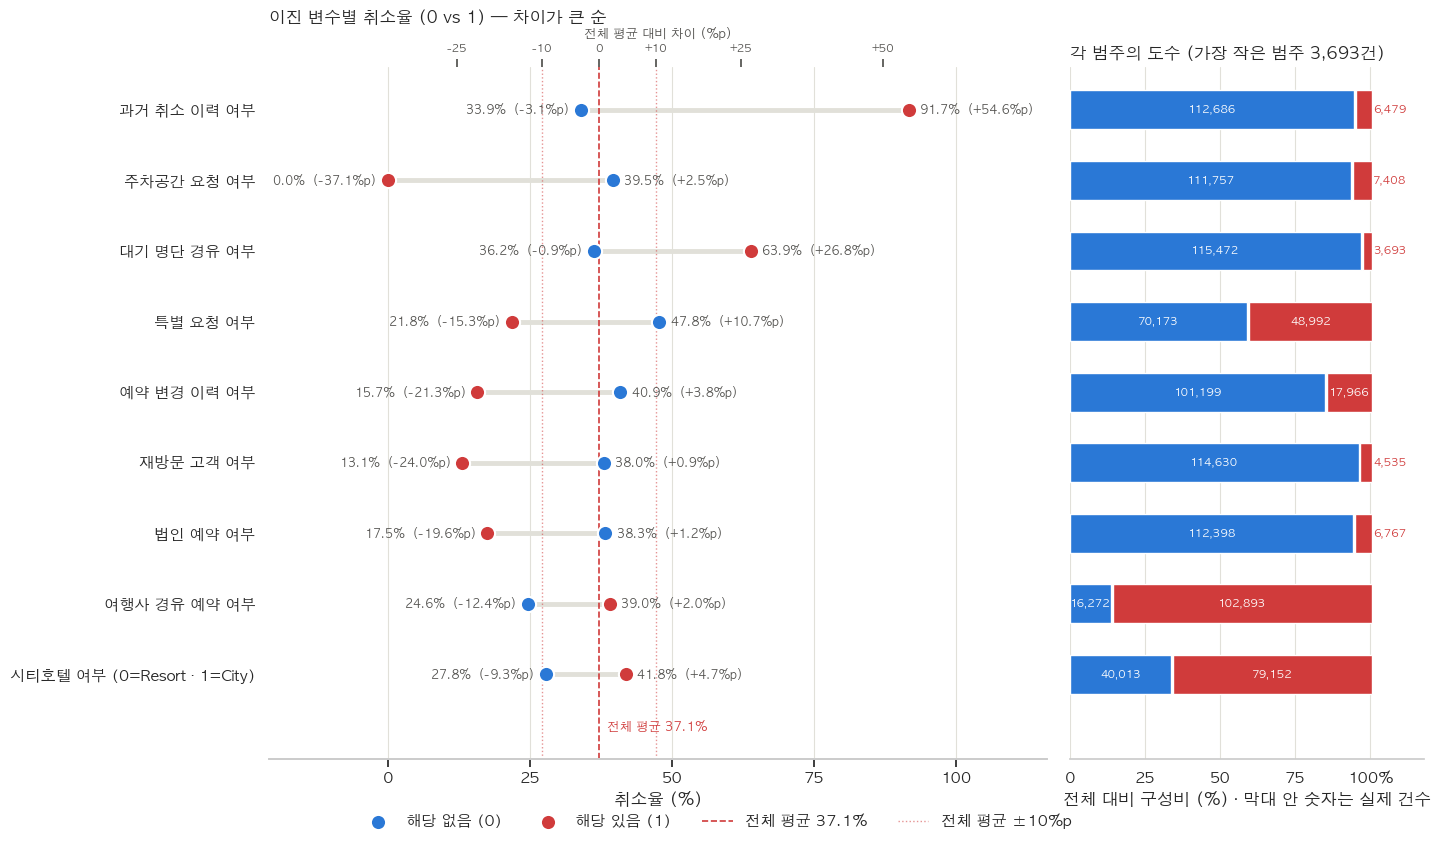

전체 취소율 37.1% · 전체 119,165건
도수 500건 미만인 범주를 가진 변수: 0개
※ 아래 괄호는 전체 평균(37.1%) 대비 차이
- 과거 취소 이력 여부: 0 → 33.9% (-3.1%p) / 1 → 91.7% (+54.6%p) · 두 범주 간 차이 +57.7%p
- 주차공간 요청 여부: 0 → 39.5% (+2.5%p) / 1 → 0.0% (-37.1%p) · 두 범주 간 차이 -39.5%p
- 대기 명단 경유 여부: 0 → 36.2% (-0.9%p) / 1 → 63.9% (+26.8%p) · 두 범주 간 차이 +27.7%p
- 특별 요청 여부: 0 → 47.8% (+10.7%p) / 1 → 21.8% (-15.3%p) · 두 범주 간 차이 -26.0%p


In [234]:
# categorical column 중 binary인 컬럼과, numeric columns 중 binary로 나눌 수 있는 컬럼을 추린다. 
# 각 binary 컬럼마다 0과 1별로 도수(frequency)와 취소율(is_canceled 비율)을 표로 나타낸다.
# 표로 그린 내용을 그래프로 시각화한다. 
# 그래프에는 특정 범주(0 or 1)의 도수를 반드시 표시한다. 도수가 충분치 않으면 취소율이 100%가 되어 유의미한 것 처럼 보일 수 있기 때문이다.

# 앞에서 규칙 검증까지 끝낸 full_data_cln_valid를 분석 대상으로 삼는다.
# 이진화 기준은 "값이 0인가 아닌가"이다. 횟수/건수형 컬럼은 값의 크기보다 '있었다/없었다'가 먼저 봐야 할 신호이기 때문이다.
#   - previous_cancellations  -> 과거에 취소한 적이 있는 고객인가
#   - booking_changes         -> 예약을 손본 적이 있는가
#   - agent / company         -> 여행사(법인)를 거친 예약인가 (앞서 결측을 0 = '거치지 않음'으로 대치했다)
#   - required_car_parking_spaces / total_of_special_requests -> 요청을 남긴 적이 있는가
#   - days_in_waiting_list    -> 대기 명단을 거쳤는가 (0이 96.9%라 값 자체보다 경유 여부가 의미 있다)
# 여기에 원래부터 값이 2개인 범주형 hotel, is_repeated_guest를 더한다.

df_bin = full_data_cln_valid
MIN_FREQ = 500   # 이 미만이면 취소율을 신뢰하지 않는다는 기준

binary_cols = {
    '시티호텔 여부 (0=Resort · 1=City)': (df_bin['hotel'] == 'City Hotel').astype(int),
    '재방문 고객 여부':                   df_bin['is_repeated_guest'],
    '과거 취소 이력 여부':                (df_bin['previous_cancellations'] > 0).astype(int),
    '예약 변경 이력 여부':                (df_bin['booking_changes'] > 0).astype(int),
    '여행사 경유 예약 여부':              (df_bin['agent'] > 0).astype(int),
    '법인 예약 여부':                     (df_bin['company'] > 0).astype(int),
    '주차공간 요청 여부':                 (df_bin['required_car_parking_spaces'] > 0).astype(int),
    '특별 요청 여부':                     (df_bin['total_of_special_requests'] > 0).astype(int),
    '대기 명단 경유 여부':                (df_bin['days_in_waiting_list'] > 0).astype(int),
}

BASE_RATE = df_bin['is_canceled'].mean()   # 전체 취소율. 모든 비교의 기준선이 된다.

# 표: 범주(0/1)별 도수 · 구성비 · 취소율
rows = []
for name, s in binary_cols.items():
    g = df_bin.groupby(s.rename('value'))['is_canceled'].agg(['size', 'mean']).reindex([0, 1])
    rows.append({
        '변수': name,
        '0 도수': int(g.loc[0, 'size']), '0 비율(%)': g.loc[0, 'size'] / len(df_bin) * 100,
        '0 취소율(%)': g.loc[0, 'mean'] * 100,
        '1 도수': int(g.loc[1, 'size']), '1 비율(%)': g.loc[1, 'size'] / len(df_bin) * 100,
        '1 취소율(%)': g.loc[1, 'mean'] * 100,
    })

df_binary_summary = pd.DataFrame(rows).set_index('변수')
# 취소율만 보면 그 값이 전체 평균보다 높은 쪽인지 낮은 쪽인지가 바로 읽히지 않는다.
# 그래서 각 범주의 취소율에서 전체 평균을 뺀 값(%p)을 같이 둔다. 부호가 곧 '평균보다 위험한 범주인가'를 뜻한다.
df_binary_summary['0 vs 평균(%p)'] = df_binary_summary['0 취소율(%)'] - BASE_RATE * 100
df_binary_summary['1 vs 평균(%p)'] = df_binary_summary['1 취소율(%)'] - BASE_RATE * 100
df_binary_summary['1-0 차이(%p)'] = df_binary_summary['1 취소율(%)'] - df_binary_summary['0 취소율(%)']
df_binary_summary['최소 도수'] = df_binary_summary[['0 도수', '1 도수']].min(axis=1)
df_binary_summary = df_binary_summary.sort_values('1-0 차이(%p)', key=abs, ascending=False)
df_binary_summary = df_binary_summary[['0 도수', '0 비율(%)', '0 취소율(%)', '0 vs 평균(%p)',
                                       '1 도수', '1 비율(%)', '1 취소율(%)', '1 vs 평균(%p)',
                                       '1-0 차이(%p)', '최소 도수']]

display(df_binary_summary.round(1))

# 시각화
# - (좌) 0에서 1로 갈 때 취소율이 어디서 어디로 움직이는지를 아령(dumbbell) 모양으로 그린다. 두 점 사이의 거리가 곧 효과 크기다.
# - (우) 그 취소율이 몇 건 위에서 계산된 값인지 도수를 함께 그린다. 왼쪽 그래프만 보면 3,693건짜리 범주와 115,472건짜리 범주가 같은 무게로 보이기 때문이다.
plot_df = df_binary_summary.iloc[::-1]   # 차이가 큰 변수가 위로 오도록 뒤집는다
y = np.arange(len(plot_df))

fig, (ax_rate, ax_cnt) = plt.subplots(1, 2, figsize=(14.5, 0.66 * len(plot_df) + 2.4),
                                      gridspec_kw={'width_ratios': [2.2, 1]}, sharey=True)

ax_rate.hlines(y, plot_df['0 취소율(%)'], plot_df['1 취소율(%)'], color=COLOR_GRID, linewidth=3.5, zorder=1)
ax_rate.scatter(plot_df['0 취소율(%)'], y, s=120, color=COLOR_OK, zorder=3,
                edgecolor='white', linewidth=1.5, label='해당 없음 (0)')
ax_rate.scatter(plot_df['1 취소율(%)'], y, s=120, color=COLOR_BAD, zorder=3,
                edgecolor='white', linewidth=1.5, label='해당 있음 (1)')
BAND = 10   # 전체 평균에서 이만큼(%p) 이상 벌어지면 '평균과 다른 집단'으로 본다는 기준선
ax_rate.axvline(BASE_RATE * 100, linestyle='--', color=COLOR_BAD, linewidth=1.2, zorder=2)
for d in (-BAND, BAND):
    ax_rate.axvline(BASE_RATE * 100 + d, linestyle=':', color=COLOR_BAD, alpha=0.55, linewidth=1, zorder=2)
ax_rate.text(BASE_RATE * 100 + 1.5, -0.8, f'전체 평균 {BASE_RATE * 100:.1f}%', color=COLOR_BAD, fontsize=9)

# 점마다 '취소율 (평균 대비 %p)'를 함께 적는다. 괄호 안 부호가 양수면 평균보다 취소가 잦은 범주다.
for i, (r0, r1) in enumerate(zip(plot_df['0 취소율(%)'], plot_df['1 취소율(%)'])):
    lo, hi = min(r0, r1), max(r0, r1)
    ax_rate.text(lo - 2, i, f'{lo:.1f}%  ({lo - BASE_RATE * 100:+.1f}%p)',
                 ha='right', va='center', fontsize=8.5, color=COLOR_INK)
    ax_rate.text(hi + 2, i, f'{hi:.1f}%  ({hi - BASE_RATE * 100:+.1f}%p)',
                 ha='left', va='center', fontsize=8.5, color=COLOR_INK)

ax_rate.set_xlim(-21, 116)
ax_rate.set_ylim(-1.2, len(plot_df) - 0.4)
ax_rate.set_yticks(y, plot_df.index)
ax_rate.set_xticks([0, 25, 50, 75, 100])
ax_rate.set_xlabel('취소율 (%)')

# 같은 축을 눈금만 바꿔 위쪽에 한 번 더 단다. 축을 하나 더 만드는 게 아니라 같은 축을
# '전체 평균 = 0'으로 옮겨 읽는 것이라, 점의 위치가 곧 평균 대비 %p가 된다.
ax_delta = ax_rate.twiny()
ax_delta.set_xlim(ax_rate.get_xlim())
delta_ticks = [-25, -BAND, 0, BAND, 25, 50]
ax_delta.set_xticks([BASE_RATE * 100 + d for d in delta_ticks], [f'{d:+d}' if d else '0' for d in delta_ticks])
ax_delta.set_xlabel('전체 평균 대비 차이 (%p)', fontsize=9, color=COLOR_INK)
ax_delta.tick_params(axis='x', labelsize=8, colors=COLOR_INK)
ax_delta.spines[['top', 'right', 'left']].set_visible(False)
ax_delta.grid(visible=False)

ax_rate.set_title('이진 변수별 취소율 (0 vs 1) — 차이가 큰 순', loc='left', pad=32)
ax_rate.spines[['top', 'right', 'left']].set_visible(False)
ax_rate.grid(axis='x', color=COLOR_GRID, linewidth=0.8)
ax_rate.grid(axis='y', visible=False)
ax_rate.set_axisbelow(True)

share0 = plot_df['0 비율(%)'].values
share1 = plot_df['1 비율(%)'].values
ax_cnt.barh(y, share0, height=0.55, color=COLOR_OK)
ax_cnt.barh(y, share1, height=0.55, left=share0 + 0.6, color=COLOR_BAD)   # 0.6%p 간격으로 두 면을 띄운다

for i, (n0, n1, s0, s1) in enumerate(zip(plot_df['0 도수'], plot_df['1 도수'], share0, share1)):
    ax_cnt.text(s0 / 2, i, f'{n0:,}', ha='center', va='center', fontsize=8, color='white')
    if s1 >= 14:   # 막대가 좁으면 숫자가 삐져나오므로 바깥에 쓴다
        ax_cnt.text(s0 + 0.6 + s1 / 2, i, f'{n1:,}', ha='center', va='center', fontsize=8, color='white')
    else:
        ax_cnt.text(101, i, f'{n1:,}', ha='left', va='center', fontsize=8, color=COLOR_BAD)

ax_cnt.set_xlim(0, 118)
ax_cnt.set_xticks([0, 25, 50, 75, 100], ['0', '25', '50', '75', '100%'])
ax_cnt.set_xlabel('전체 대비 구성비 (%) · 막대 안 숫자는 실제 건수')
ax_cnt.set_title(f'각 범주의 도수 (가장 작은 범주 {plot_df["최소 도수"].min():,}건)', loc='left')
ax_cnt.spines[['top', 'right', 'left']].set_visible(False)
ax_cnt.grid(axis='x', color=COLOR_GRID, linewidth=0.8)
ax_cnt.grid(axis='y', visible=False)
ax_cnt.set_axisbelow(True)

from matplotlib.lines import Line2D

handles, labels = ax_rate.get_legend_handles_labels()
handles += [Line2D([], [], color=COLOR_BAD, linestyle='--', linewidth=1.2),
            Line2D([], [], color=COLOR_BAD, linestyle=':', alpha=0.55, linewidth=1)]
labels += [f'전체 평균 {BASE_RATE * 100:.1f}%', f'전체 평균 ±{BAND}%p']
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

print(f"전체 취소율 {BASE_RATE * 100:.1f}% · 전체 {len(df_bin):,}건")
low = df_binary_summary[df_binary_summary['최소 도수'] < MIN_FREQ]
print(f"도수 {MIN_FREQ}건 미만인 범주를 가진 변수: {len(low)}개"
      + ("" if low.empty else f" -> {list(low.index)}"))
print(f"※ 아래 괄호는 전체 평균({BASE_RATE * 100:.1f}%) 대비 차이")
for name, r in df_binary_summary.head(4).iterrows():
    print(f"- {name}: 0 → {r['0 취소율(%)']:.1f}% ({r['0 vs 평균(%p)']:+.1f}%p)"
          f" / 1 → {r['1 취소율(%)']:.1f}% ({r['1 vs 평균(%p)']:+.1f}%p)"
          f" · 두 범주 간 차이 {r['1-0 차이(%p)']:+.1f}%p")

# [해석]
# 0. 읽는 법: 점 옆 괄호와 위쪽 축은 전체 평균(37.1%) 대비 차이(%p)이고, 세로 점선이 0%p(= 전체 평균)이다.
#    - 구성비가 큰 범주는 그 자체가 평균을 만들기 때문에 평균에서 멀어질 수 없다.
#      여행사 경유 예약(86.3%)이 +2.0%p인데 반대편인 비경유(13.7%)는 -12.4%p인 것이 그 예다.
#    - 즉 평균 대비 차이는 도수가 작은 쪽에서 더 크게 벌어지고, 그 쪽이 개입 대상 집단을 좁게 특정해 준다.
#      '특별 요청 여부'처럼 양쪽 도수가 비슷한(58.9% vs 41.1%) 변수만이 양쪽 모두 +10.7%p / -15.3%p로 크게 벌어진다.
#
# 1. 도수부터 확인하면, 가장 작은 범주도 3,693건이라 9개 변수 모두 취소율을 그대로 읽어도 된다.
#
# 2. 과거 취소 이력 여부 (33.9% -> 91.7%, +57.7%p)
#    - 한 번이라도 취소한 적이 있는 고객은 10명 중 9명이 또 취소한다. 단일 변수로는 가장 강한 신호다.
#    - 다만 6,479건(5.4%)뿐이라, 전체 취소 건수에서 차지하는 비중 자체는 크지 않다.
#
# 3. 주차공간 요청 여부 (39.5% -> 0.0%, -39.5%p) : 해석에 주의가 필요한 변수다.
#    - 주차 요청이 있는 7,408건은 취소가 '단 한 건도' 없다. 정상적인 관계라면 이렇게 깨끗하게 0%가 나올 수 없다.
#    - required_car_parking_spaces는 예약 시점이 아니라 실제 투숙(체크인) 시점에 채워지는 값으로 보이고,
#      그렇다면 취소된 예약은 애초에 이 값을 가질 수 없다. 즉 결과(취소되지 않음)가 원인처럼 보이는 데이터 누수(leakage)다.
#    - 따라서 "주차 요청을 유도하면 취소가 줄어든다"고 읽으면 안 되고, 예측 모델을 만든다면 이 컬럼은 제외해야 한다.
#
# 4. 고객이 예약에 손을 댄 흔적이 있으면 취소율이 크게 낮아진다.
#    - 특별 요청 있음 21.8% vs 없음 47.8%, 예약 변경 있음 15.7% vs 없음 40.9%.
#    - 두 변수 모두 예약 시점 이후 고객이 능동적으로 남긴 행동이므로, 3번과 달리 취소 방지 아이디어로 연결할 수 있다.
#
# 5. 재방문 고객(13.1%)과 법인 예약(17.5%)은 취소율이 낮고, 여행사 경유 예약(39.0%)과 시티호텔(41.8%)은 높다.
#    - 즉 '호텔과 직접 관계가 있는 예약'일수록 덜 취소된다.
#
# 6. 대기 명단을 거친 예약은 63.9%가 취소된다. 방이 없어 대기했다는 것 자체가 이탈 위험 신호다.

도수  구성비(%)  취소율(%)
변수           계급                              
리드타임 (예약~도착) 당일          6264    5.26     6.7
             1~7일       13368   11.22    11.0
             8~30일      18942   15.90    27.9
             31~90일     29520   24.77    37.7
             91~180일    26417   22.17    44.7
             181~365일   21507   18.05    55.5
             366일+       3147    2.64    67.7
총 숙박일수       0박           645    0.54     3.6
             1박         21001   17.62    25.1
             2~3박       54688   45.89    43.0
             4~7박       37617   31.57    35.9
             8~14박       4785    4.02    34.2
             15박+         429    0.36    56.4
총 투숙 인원      1명         22578   18.95    29.0
             2명         82031   68.84    39.7
             3명         10492    8.80    32.2
             4명          3926    3.29    41.9
             5명+          138    0.12    26.1
도착 월         1월          5920    4.97    30.5
             2월          8052    6.76    33.4
             3월          9768    8.20    32.2
             4월         11078    9.30    40.8
             5월         11779    9.88    39.7
             6월         10922    9.17    41.5
             7월         12635   10.60    37.5
             8월         13859   11.63    37.8
             9월         10486    8.80    39.2
             10월        11139    9.35    38.1
             11월         6771    5.68    31.3
             12월         6756    5.67    35.0
도착 연도        2015       21942   18.41    37.0
             2016       56607   47.50    35.9
             2017       40616   34.08    38.7
과거 취소 횟수     0회        112686   94.56    33.9
             1회          6048    5.08    94.4
             2~5회         229    0.19    29.3
             6회+          202    0.17    79.7
과거 정상 이용 횟수  0회        115552   96.97    38.1
             1회          1538    1.29     5.1
             2~5회        1323    1.11     5.4
             6회+          752    0.63     6.5
예약 변경 횟수     0회        101199   84.92    40.9
             1회         12661   10.62    14.2
             2회          3774    3.17    20.3
             3회+         1531    1.28    17.0
특별 요청 건수     0건         70173   58.89    47.8
             1건         33171   27.84    22.0
             2건         12947   10.86    22.1
             3건+         2874    2.41    16.8
대기 명단 일수     0일        115472   96.90    36.2
             1~7일         128    0.11    61.7
             8~30일        463    0.39    79.5
             31일+        3102    2.60    61.6

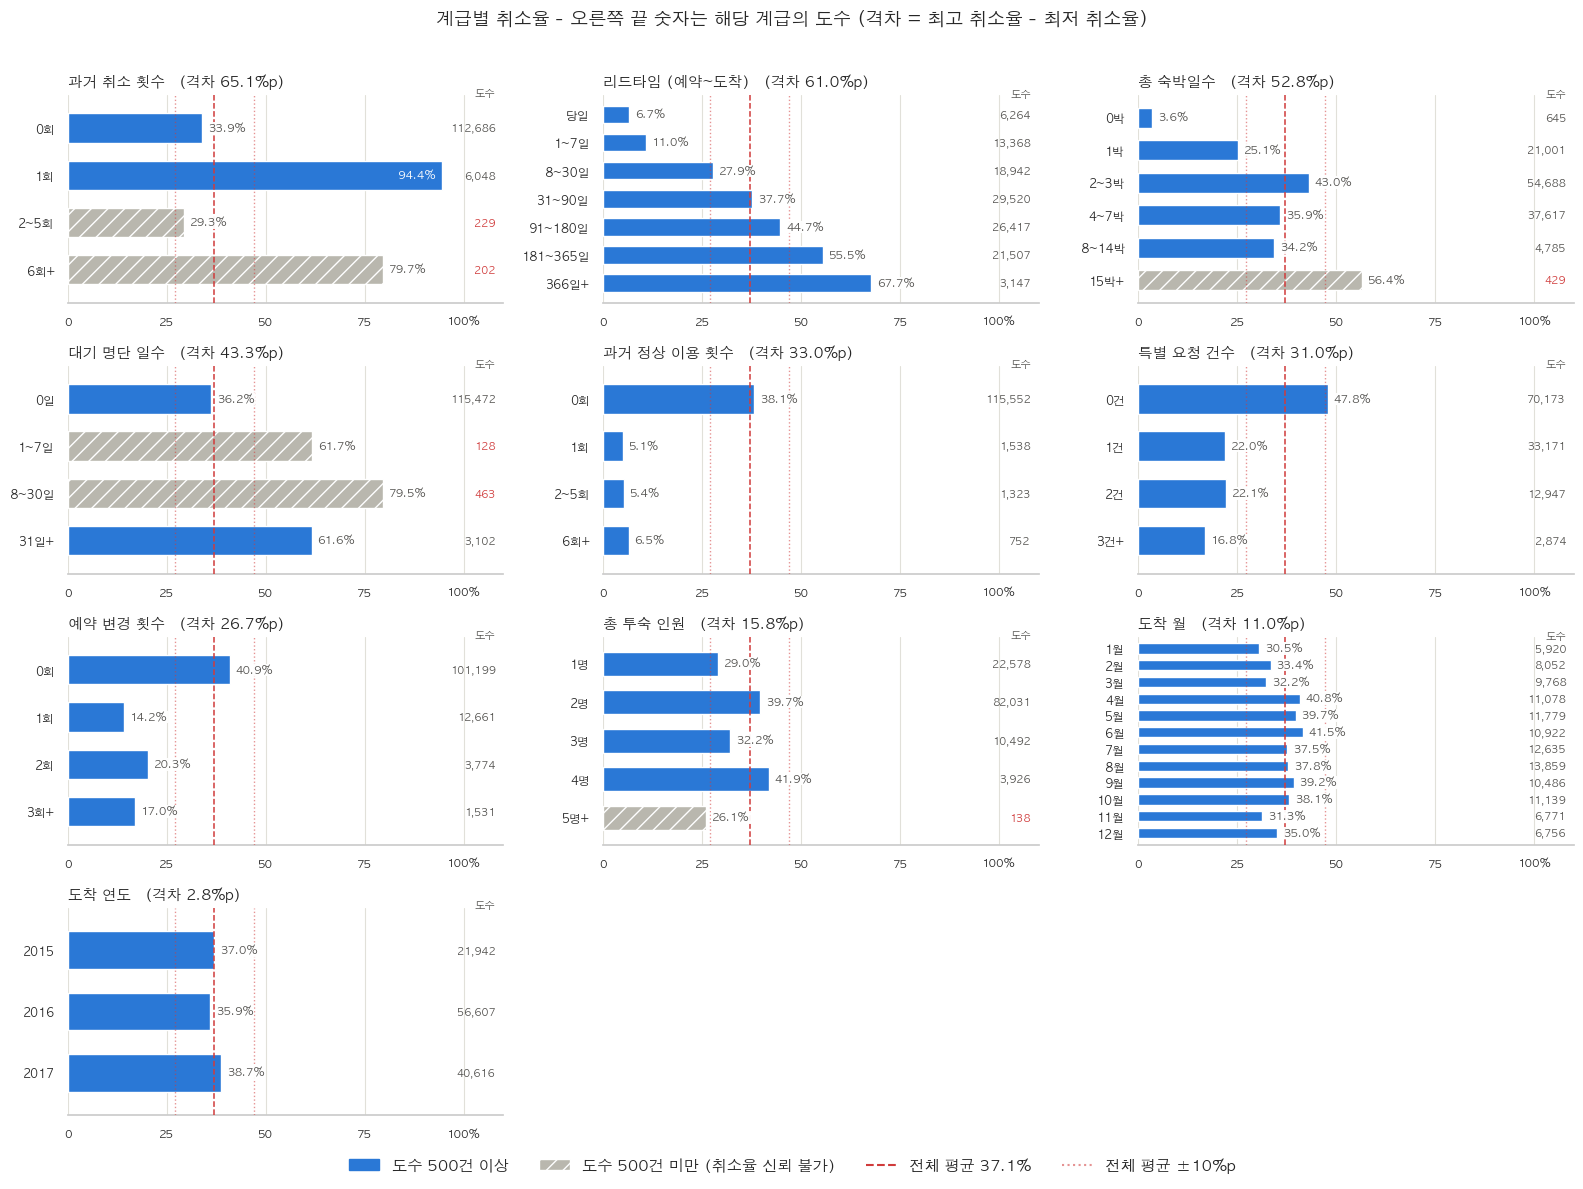

전체 취소율 37.1% · 전체 119,165건
도수 500건 미만이라 취소율을 신뢰할 수 없는 계급: 6개


도수  구성비(%)  취소율(%)
변수       계급                        
총 숙박일수   15박+   429    0.36    56.4
총 투숙 인원  5명+    138    0.12    26.1
과거 취소 횟수 2~5회   229    0.19    29.3
         6회+    202    0.17    79.7
대기 명단 일수 1~7일   128    0.11    61.7
         8~30일  463    0.39    79.5

In [235]:
# numeric columns 중 Low Cardinality를 나눌 수 있는 컬럼을 추린다. Binary 유형으로 분석되었던 컬럼도 Low Cardinality 유형으로 다시 분석될 수 있다. 
# 각 컬럼의 비즈니스적 의미와 통계적 특성에 따라 계급(Class)의 구간을 다르게 산정해야 한다. 
# 각 계급별로 도수와 취소율을 표로 나타낸다. 
# 표로 그린 내용을 시각화한다. 
# 그래프에는 계급의 도수를 반드시 도수가 충분치 않으면 취소율이 100%가 되어 유의미한 것 처럼 보일 수 있기 때문이다.

# 계급 구간은 통계값(분위수)이 아니라 비즈니스적으로 의미가 끊기는 지점을 기준으로 잡는다.
#   - 리드타임/대기일수 같은 기간형: 당일 · 1주 · 1달 · 분기 · 반년 · 1년처럼 실무에서 쓰는 시간 단위로 끊는다.
#   - 숙박일수: 0박(당일) · 1박 · 주말(2~3박) · 일주일(4~7박) · 장기(8박+)로 끊는다.
#   - 횟수/건수형: 0 · 1 · 소수 · 다수로 끊는다. 앞의 이진 분석에서 0과 1의 차이가 가장 컸으므로 그 경계를 살리고,
#     값이 커질수록 표본이 급격히 줄기 때문에 뒤쪽은 묶어야 한다.
# 분위수로 자르면 previous_cancellations처럼 94.6%가 0인 컬럼은 계급이 아예 나뉘지 않는다는 점도 이유다.

df_lc = full_data_cln_valid.copy()
df_lc['total_guests'] = df_lc['adults'] + df_lc['children'] + df_lc['babies']

BASE_RATE = df_lc['is_canceled'].mean()
MIN_FREQ = 500          # 이 미만인 계급은 취소율을 신뢰하지 않는다
BAND = 10               # 전체 평균에서 이만큼(%p) 이상 벌어진 계급만 '의미 있게 다르다'고 본다
COLOR_THIN = '#b9b7ae'  # 도수가 부족한 계급을 칠할 색

MONTH_ORDER = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
MONTH_KO = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']

def cut(col, bins, labels):
    return pd.cut(df_lc[col], bins=bins, labels=labels, right=True, include_lowest=True)

lowcard_cols = {
    '리드타임 (예약~도착)': cut('lead_time', [-1, 0, 7, 30, 90, 180, 365, 10**4],
                                ['당일', '1~7일', '8~30일', '31~90일', '91~180일', '181~365일', '366일+']),
    '총 숙박일수':          cut('total_nights', [-1, 0, 1, 3, 7, 14, 10**4],
                                ['0박', '1박', '2~3박', '4~7박', '8~14박', '15박+']),
    '총 투숙 인원':         cut('total_guests', [0, 1, 2, 3, 4, 100], ['1명', '2명', '3명', '4명', '5명+']),
    '도착 월':              pd.Series(pd.Categorical(df_lc['arrival_date_month'].map(dict(zip(MONTH_ORDER, MONTH_KO))),
                                                     categories=MONTH_KO, ordered=True), index=df_lc.index),
    '도착 연도':            df_lc['arrival_date_year'].astype(str),
    '과거 취소 횟수':       cut('previous_cancellations', [-1, 0, 1, 5, 10**4], ['0회', '1회', '2~5회', '6회+']),
    '과거 정상 이용 횟수':  cut('previous_bookings_not_canceled', [-1, 0, 1, 5, 10**4], ['0회', '1회', '2~5회', '6회+']),
    '예약 변경 횟수':       cut('booking_changes', [-1, 0, 1, 2, 10**4], ['0회', '1회', '2회', '3회+']),
    '특별 요청 건수':       cut('total_of_special_requests', [-1, 0, 1, 2, 10**4], ['0건', '1건', '2건', '3건+']),
    '대기 명단 일수':       cut('days_in_waiting_list', [-1, 0, 7, 30, 10**4], ['0일', '1~7일', '8~30일', '31일+']),
}

tables = {}
for name, s in lowcard_cols.items():
    g = df_lc.groupby(s.rename('계급'), observed=True)['is_canceled'].agg(도수='size', 취소율='mean')
    g['구성비(%)'] = (g['도수'] / len(df_lc) * 100).round(2)
    g['취소율(%)'] = (g['취소율'] * 100).round(1)
    tables[name] = g[['도수', '구성비(%)', '취소율(%)']]

df_lowcard_summary = pd.concat(tables, names=['변수'])
display(df_lowcard_summary)

# 시각화
# - 변수 하나당 패널 하나. 취소율 축을 0~100%로 고정해, 패널이 달라도 막대 길이를 그대로 비교할 수 있게 한다.
# - 격차(최고 취소율 - 최저 취소율)가 큰 변수부터 배치해 어떤 변수가 취소를 더 크게 가르는지 순서로 드러낸다.
# - 도수가 MIN_FREQ 미만인 계급은 회색 빗금으로 칠해, 취소율이 튀어 보여도 근거가 얇다는 것을 색으로 구분한다.
order = sorted(tables, key=lambda k: tables[k]['취소율(%)'].max() - tables[k]['취소율(%)'].min(), reverse=True)

ncols = 3
nrows = int(np.ceil(len(order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 2.9 * nrows))
axes = axes.ravel()

for ax, name in zip(axes, order):
    t = tables[name].iloc[::-1]   # 첫 계급이 위로 오도록 뒤집는다
    y = np.arange(len(t))
    bars = ax.barh(y, t['취소율(%)'], height=0.62,
                   color=[COLOR_OK if n >= MIN_FREQ else COLOR_THIN for n in t['도수']])
    for b, n in zip(bars, t['도수']):
        if n < MIN_FREQ:
            b.set_hatch('//')

    for i, (rate, n) in enumerate(zip(t['취소율(%)'], t['도수'])):
        if rate > 80:   # 막대가 길면 라벨을 안쪽에 넣어 오른쪽 도수 열과 겹치지 않게 한다
            ax.text(rate - 1.5, i, f'{rate:.1f}%', ha='right', va='center', fontsize=8, color='white', zorder=5)
        else:
            ax.text(rate + 1.5, i, f'{rate:.1f}%', va='center', fontsize=8, color=COLOR_INK, zorder=5,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.95, pad=0.6))
        ax.text(108, i, f'{n:,}', va='center', ha='right', fontsize=7.5,
                color=COLOR_INK if n >= MIN_FREQ else COLOR_BAD)

    ax.axvline(BASE_RATE * 100, linestyle='--', color=COLOR_BAD, linewidth=1.1, zorder=3)
    for d in (-BAND, BAND):   # 평균 ±BAND%p 밖으로 나간 계급이 실제로 눈에 띄는 계급이다
        ax.axvline(BASE_RATE * 100 + d, linestyle=':', color=COLOR_BAD, alpha=0.55, linewidth=1, zorder=3)
    ax.text(108, len(t) - 0.25, '도수', ha='right', va='center', fontsize=7.5, color=COLOR_INK)
    ax.set_title(f'{name}   (격차 {t["취소율(%)"].max() - t["취소율(%)"].min():.1f}%p)', fontsize=10.5, loc='left')
    ax.set_yticks(y, t.index.astype(str), fontsize=8.5)
    ax.set_xlim(0, 110)
    ax.set_ylim(-0.7, len(t) - 0.3)
    ax.set_xticks([0, 25, 50, 75, 100], ['0', '25', '50', '75', '100%'], fontsize=8)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='x', color=COLOR_GRID, linewidth=0.8)
    ax.grid(axis='y', visible=False)
    ax.set_axisbelow(True)

for ax in axes[len(order):]:
    ax.remove()

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig.legend(handles=[mpatches.Patch(color=COLOR_OK, label=f'도수 {MIN_FREQ}건 이상'),
                    mpatches.Patch(facecolor=COLOR_THIN, hatch='//', label=f'도수 {MIN_FREQ}건 미만 (취소율 신뢰 불가)'),
                    Line2D([], [], color=COLOR_BAD, linestyle='--', label=f'전체 평균 {BASE_RATE * 100:.1f}%'),
                    Line2D([], [], color=COLOR_BAD, linestyle=':', alpha=0.55, label=f'전체 평균 ±{BAND}%p')],
           loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('계급별 취소율 - 오른쪽 끝 숫자는 해당 계급의 도수 (격차 = 최고 취소율 - 최저 취소율)', fontsize=13, y=1.005)
plt.tight_layout(rect=[0, 0.015, 1, 0.995])
plt.show()

thin = df_lowcard_summary[df_lowcard_summary['도수'] < MIN_FREQ]
print(f"전체 취소율 {BASE_RATE * 100:.1f}% · 전체 {len(df_lc):,}건")
print(f"도수 {MIN_FREQ}건 미만이라 취소율을 신뢰할 수 없는 계급: {len(thin)}개")
display(thin)

# [해석]
# 1. 리드타임이 가장 깔끔한 단조 증가를 보인다. 당일 6.7% -> 1~7일 11.0% -> 31~90일 37.7% -> 366일+ 67.7%.
#    - 예약을 일찍 잡을수록 취소한다. 도중에 계획이 바뀔 시간이 그만큼 길기 때문으로 보인다.
#    - 계급마다 도수가 3,147건 이상이라 이 추세는 그대로 믿어도 된다. 취소 위험을 예측할 때 1순위로 쓸 변수다.
#
# 2. 도수 표기가 왜 필요한지가 '과거 취소 횟수'와 '대기 명단 일수'에서 그대로 드러난다.
#    - 과거 취소 1회는 94.4%(6,048건)로 신뢰할 수 있지만, 2~5회는 29.3%(229건), 6회+는 79.7%(202건)로 오르내린다.
#      도수를 표기하지 않았다면 "2~5회 취소한 고객은 오히려 잘 안 취소한다"는 잘못된 결론을 내렸을 것이다.
#    - 대기 명단도 8~30일 구간이 79.5%로 가장 높아 보이지만 463건뿐이다. 반면 0일(115,472건)과 31일+(3,102건)의
#      36.2% vs 61.6% 차이는 도수가 충분하므로, "대기를 거친 예약은 취소 위험이 높다"까지만 말할 수 있다.
#
# 3. 고객의 관여도를 나타내는 변수들은 0에서 1로 갈 때 효과가 가장 크고, 그 뒤로는 거의 평평하다.
#    - 특별 요청: 0건 47.8% -> 1건 22.0% -> 2건 22.1% -> 3건+ 16.8%
#    - 예약 변경: 0회 40.9% -> 1회 14.2% -> 2회 20.3% -> 3회+ 17.0%
#    - 즉 요청이나 변경을 '많이' 하게 만드는 것이 아니라, '한 번이라도' 하게 만드는 것이 핵심이다.
#
# 4. 과거 정상 이용 횟수는 0회 38.1%에서 1회 5.1%로 떨어진다. 한 번이라도 실제로 묵어본 고객은 거의 취소하지 않는다.
#
# 5. 총 숙박일수는 0박(3.6%)/1박(25.1%)이 낮고 2~3박(43.0%)에서 가장 높다. 짧은 숙박일수록 취소 부담이 작아서 그런 것이 아니라,
#    0박·1박에 당일/단기 예약이 몰려 있기 때문으로 보인다(리드타임과 엮인 효과라 단독 해석은 조심해야 한다).
#
# 6. 반대로 도착 월(격차 11.0%p)과 도착 연도(격차 2.8%p)는 격차가 작다.
#    - 계절이나 연도 같은 '시점' 요인보다, 예약이 어떻게 이루어졌는가 하는 '예약 행동' 요인이 취소를 훨씬 크게 가른다.

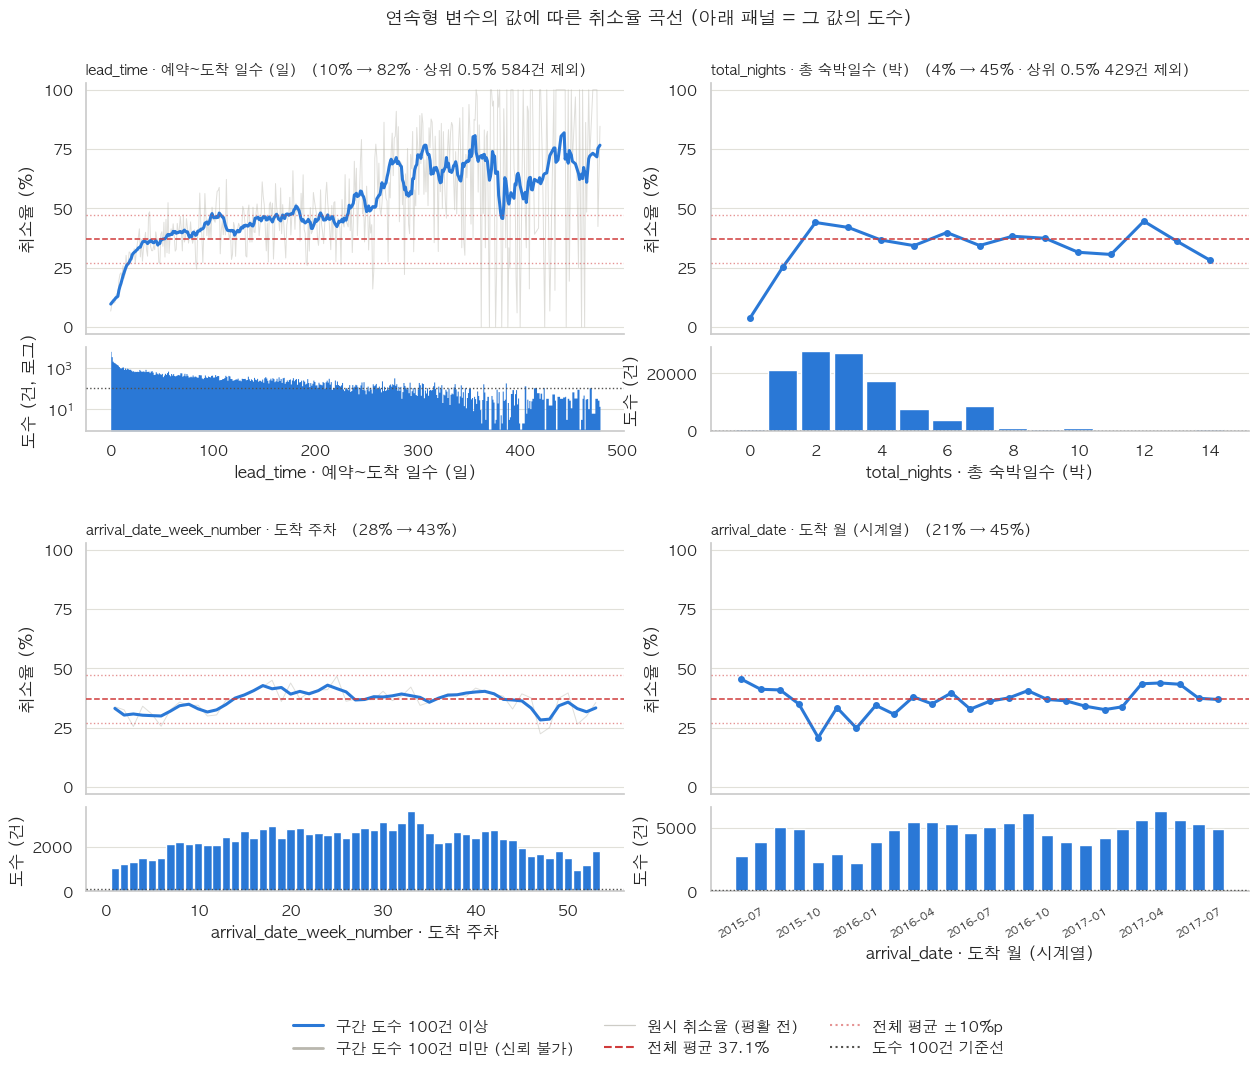

[lead_time] 값 444개 · 도수 최소 1건 / 최대 6,264건 · 전체 평균(37.1%)을 처음 넘어서는 값: 52
[total_nights] 값 15개 · 도수 최소 141건 / 최대 27,629건 · 전체 평균(37.1%)을 처음 넘어서는 값: 2
[arrival_date_week_number] 값 53개 · 도수 최소 932건 / 최대 3,576건 · 전체 평균(37.1%)을 처음 넘어서는 값: 14
[arrival_month] 값 26개 · 도수 최소 2,247건 / 최대 6,305건 · 전체 평균(37.1%)을 처음 넘어서는 값: 2015-07-01 00:00:00


In [236]:
# numeric columns 중 Continuous, High Cardinality이라고 판단되는 컬럼을 추린다. 
# 연속적으로 이어지는 값에 따라 취소율을 그래프로 그린다. 
# 그래프에는 각 값의 도수를 같이 표기한다. 도수가 충분치 않으면 취소율이 100%가 되어 유의미한 것 처럼 보일 수 있기 때문이다.

# 고유값이 많더라도 '값 사이의 거리'가 의미를 가져야 연속형으로 볼 수 있다.
#   - lead_time(479개), total_nights, arrival_date_week_number, arrival_date : 값이 클수록 기간이 길다는 뜻이므로 연속형이다.
#   - agent(334개) / company(349개) / country(177개) : 고유값은 많지만 ID·코드라 1번과 2번 사이의 거리에 의미가 없다. 따라서 제외한다.
# 앞의 계급 분석은 구간을 사람이 정했지만, 여기서는 값 하나하나를 그대로 따라가며 어디서 취소율이 꺾이는지를 본다.

df_cont = full_data_cln_valid.copy()
df_cont['arrival_month'] = df_cont['arrival_date'].dt.to_period('M').dt.to_timestamp()

BASE_RATE = df_cont['is_canceled'].mean()
MIN_FREQ = 100          # 한 점의 취소율을 믿기 위해 필요한 최소 도수
BAND = 10               # 전체 평균 ±BAND%p 를 벗어나는 구간이 실제로 위험/안전이 갈리는 구간이다
COLOR_THIN = '#b9b7ae'

# (컬럼, x축 이름, 이동평균 창 크기, x축 상한 분위수)
# 값 하나당 도수가 적은 컬럼은 원시 취소율이 0%와 100%를 오가며 튄다. 그래서 도수로 가중한 이동평균을 함께 그린다.
# (단순 평균이 아니라 '창 안의 취소 건수 합 / 창 안의 예약 건수 합'이라, 도수가 적은 값이 곡선을 흔들지 않는다.)
continuous_specs = [
    ('lead_time',                'lead_time · 예약~도착 일수 (일)',      15, 0.995),
    ('total_nights',             'total_nights · 총 숙박일수 (박)',       1, 0.995),
    ('arrival_date_week_number', 'arrival_date_week_number · 도착 주차',  3, 1.0),
    ('arrival_month',            'arrival_date · 도착 월 (시계열)',       1, 1.0),
]

def curve(col, window):
    """값별 도수와 취소율. window > 1이면 도수로 가중한 이동평균을 함께 낸다."""
    g = df_cont.groupby(col)['is_canceled'].agg(도수='size', 취소='sum')
    g['취소율(%)'] = g['취소'] / g['도수'] * 100
    if window > 1:
        num = g['취소'].rolling(window, center=True, min_periods=1).sum()
        den = g['도수'].rolling(window, center=True, min_periods=1).sum()
        g['평활 취소율(%)'] = num / den * 100
        g['창 도수'] = den   # 이 창 안에서 몇 건을 근거로 계산했는지
    else:
        g['평활 취소율(%)'] = g['취소율(%)']
        g['창 도수'] = g['도수']
    return g

# 시각화: 변수마다 위(취소율 곡선) / 아래(도수) 두 칸을 x축을 공유하도록 붙여 그린다.
# 도수를 같은 그림에 y축 2개로 넣으면 두 축의 눈금이 서로를 왜곡하므로, 축을 나누고 x만 공유한다.
fig = plt.figure(figsize=(15, 10.5))
outer = fig.add_gridspec(2, 2, hspace=0.32, wspace=0.16)
tables_cont = {}

for k, (col, xlabel, window, qmax) in enumerate(continuous_specs):
    inner = outer[divmod(k, 2)].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax_rate = fig.add_subplot(inner[0])
    ax_cnt = fig.add_subplot(inner[1], sharex=ax_rate)

    g = curve(col, window)
    if qmax < 1.0:   # 꼬리쪽 극단값까지 그리면 x축이 늘어나 정작 봐야 할 구간이 눌린다
        xmax = df_cont[col].quantile(qmax)
        dropped = int(g.loc[g.index > xmax, '도수'].sum())
        g = g[g.index <= xmax]
    else:
        dropped = 0
    tables_cont[col] = g
    enough = g['창 도수'] >= MIN_FREQ

    if window > 1:   # 원시 취소율은 옅게 깔아두고 평활 곡선을 주선으로 쓴다
        ax_rate.plot(g.index, g['취소율(%)'], color=COLOR_THIN, linewidth=0.7, alpha=0.45, zorder=2)
    mk = 'o' if len(g) <= 30 else None
    ax_rate.plot(g.index, g['평활 취소율(%)'].where(~enough), color=COLOR_THIN, linewidth=2,
                 zorder=3, marker=mk, markersize=4)
    ax_rate.plot(g.index, g['평활 취소율(%)'].where(enough), color=COLOR_OK, linewidth=2.2,
                 zorder=4, marker=mk, markersize=4)
    ax_rate.axhline(BASE_RATE * 100, linestyle='--', color=COLOR_BAD, linewidth=1.1, zorder=5)
    for d in (-BAND, BAND):
        ax_rate.axhline(BASE_RATE * 100 + d, linestyle=':', color=COLOR_BAD, alpha=0.55, linewidth=1, zorder=5)

    note = f' · 상위 {(1 - qmax) * 100:.1f}% {dropped:,}건 제외' if dropped else ''
    ax_rate.set_title(f'{xlabel}   ({g["평활 취소율(%)"].min():.0f}% → {g["평활 취소율(%)"].max():.0f}%{note})',
                      fontsize=10.5, loc='left')
    ax_rate.set_ylim(-3, 103)
    ax_rate.set_yticks([0, 25, 50, 75, 100])
    ax_rate.set_ylabel('취소율 (%)')
    ax_rate.tick_params(labelbottom=False)
    ax_rate.spines[['top', 'right']].set_visible(False)
    ax_rate.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
    ax_rate.grid(axis='x', visible=False)
    ax_rate.set_axisbelow(True)

    if len(g) > 100:   # 값이 촘촘하면 막대가 1픽셀 미만이 되므로 면적(area)으로 그린다
        ax_cnt.fill_between(g.index, 0.8, g['도수'], step='mid', color=COLOR_OK, linewidth=0)
        ax_cnt.fill_between(g.index, 0.8, g['도수'].where(~enough), step='mid', color=COLOR_THIN, linewidth=0)
    else:
        ax_cnt.bar(g.index, g['도수'], width=20 if col == 'arrival_month' else 0.9,
                   color=[COLOR_OK if e else COLOR_THIN for e in enough])

    if g['도수'].max() / max(g['도수'].min(), 1) > 500:   # 도수 편차가 크면 로그 축으로 꼬리까지 보이게 한다
        ax_cnt.set_yscale('log')
        ax_cnt.set_ylim(bottom=0.8)
        ax_cnt.set_ylabel('도수 (건, 로그)')
    else:
        ax_cnt.set_ylabel('도수 (건)')
    ax_cnt.axhline(MIN_FREQ, linestyle=':', color=COLOR_INK, linewidth=1, zorder=4)
    ax_cnt.set_xlabel(xlabel)
    ax_cnt.spines[['top', 'right']].set_visible(False)
    ax_cnt.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
    ax_cnt.grid(axis='x', visible=False)
    ax_cnt.set_axisbelow(True)
    if col == 'arrival_month':
        ax_cnt.tick_params(axis='x', labelrotation=30, labelsize=8)

from matplotlib.lines import Line2D

fig.legend(handles=[Line2D([], [], color=COLOR_OK, linewidth=2.2, label=f'구간 도수 {MIN_FREQ}건 이상'),
                    Line2D([], [], color=COLOR_THIN, linewidth=2, label=f'구간 도수 {MIN_FREQ}건 미만 (신뢰 불가)'),
                    Line2D([], [], color=COLOR_THIN, linewidth=0.9, alpha=0.7, label='원시 취소율 (평활 전)'),
                    Line2D([], [], color=COLOR_BAD, linestyle='--', label=f'전체 평균 {BASE_RATE * 100:.1f}%'),
                    Line2D([], [], color=COLOR_BAD, linestyle=':', alpha=0.55, label=f'전체 평균 ±{BAND}%p'),
                    Line2D([], [], color=COLOR_INK, linestyle=':', label=f'도수 {MIN_FREQ}건 기준선')],
           loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('연속형 변수의 값에 따른 취소율 곡선 (아래 패널 = 그 값의 도수)', fontsize=13, y=0.95)
plt.show()

for col, g in tables_cont.items():
    over = g[(g['평활 취소율(%)'] >= BASE_RATE * 100) & (g['창 도수'] >= MIN_FREQ)]
    cross = over.index.min() if len(over) else None
    print(f"[{col}] 값 {len(g)}개 · 도수 최소 {int(g['도수'].min()):,}건 / 최대 {int(g['도수'].max()):,}건"
          + (f" · 전체 평균({BASE_RATE * 100:.1f}%)을 처음 넘어서는 값: {cross}" if cross is not None else ""))

# [해석]
# 1. lead_time : 계급으로 묶었을 때 보이지 않던 모양이 드러난다.
#    - 0일 10%에서 시작해 30일 부근까지 가파르게 올라 35%에 이르고(하루 평균 +0.8%p), 52일에서 전체 평균 37.1%를 넘어선다.
#    - 그 뒤로는 기울기가 완만해진다. 100일 46%, 300일 73%로 300일에 걸쳐 오르는 폭이 앞의 한 달과 비슷하다.
#    - 즉 취소 위험이 만들어지는 속도는 예약 직후 한 달에 집중된다.
#      -> 리마인드나 예약 확정 요청 같은 액션도 예약 후 한 달 안에 넣는 것이 가장 효율적이라는 뜻이 된다.
#    - 400일이 넘어가면 원시 곡선(연회색)이 0%와 100%를 오간다. 아래 도수 패널을 보면 그 구간은 하루당 수십 건뿐이라,
#      평활 곡선 없이 원시값만 봤다면 "1년 이상 전 예약은 취소율이 100%"라고 잘못 읽었을 것이다.
#
# 2. total_nights : 0박 3.6%, 1박 25.1%로 낮다가 2박(44.0%)에서 꺾이고, 그 뒤로는 30~40%대에서 평평하다.
#    - 숙박일수가 길어진다고 취소가 계속 늘지는 않는다. 1박 이하냐 아니냐가 갈림길이다.
#
# 3. arrival_date_week_number : 14주차(4월 초)부터 평균을 넘고 24주차(6월 중순, 42.9%)가 가장 높으며, 47주차(11월 말, 28.2%)가 가장 낮다.
#    - 성수기일수록 취소율도 높다. 다만 최저 28% ~ 최고 43%로 폭이 좁아, 계절성은 보조 요인이다.
#
# 4. arrival_date(월별 시계열) : 2015-11(20.8%), 2016-01(24.8%) 같은 몇 달을 빼면 2년 내내 30~45% 사이에 머문다.
#    - 취소율이 특정 시점부터 구조적으로 나빠진 것이 아니라 처음부터 계속 높은 수준이었다는 뜻이므로,
#      "언제부터 나빠졌나"가 아니라 "어떤 예약이 취소되나"를 보는 것이 맞다.

## 4. 데이터 해석

- **과거 취소 이력 여부: 있으면 취소율 높음**
    - 취소 횟수가 1회일 때 취소율이 94.4%로, 가장 높았다.
    - 취소 횟수가 6회 이상이면 취소율이 79.4%로, 매우 높지만 해당 구간의 도수가 202건밖에 되지 않아 신뢰도가 떨어진다.
    - **과거 취소 횟수가 2회 이상인 구간의 도수가 431으로, 전체의 0.36%밖에 차지하지 않는다. 즉, 2회 이상 취소하면 예약 횟수 자체가 줄어든다는 것이다. 따라서 고객이 2회 이상 취소하지 않도록 유인하는 것이 필요하다.**
- **고객의 관여도: 예약 변경 이력 여부 & 특별 요청 건수: 있으면 취소율 낮음**
    - 특별 요청: 0건 47.8% -> 1건 22.0% -> 2건 22.1% -> 3건+ 16.8%
    - 예약 변경: 0회 40.9% -> 1회 14.2% -> 2회 20.3% -> 3회+ 17.0%
    - **고객이 특별 요청이나 예약 변경을 많이 하게 하는 것은 중요하지 않다. 한 번이라도 하게 만드는 것이 필요하다.**
- **재방문 여부: 있으면 취소율 낮음**
    - 재방문 고객의 취소율은 13.1%로, 재방문이 아닌 고객(38%)보다 -21.3%p 차이난다.
    - 재방문하지 않은 고객의 도수는 4535로, 신뢰도가 충분하다.
    - **따라서 과거 호텔 이용 경험이 있는 고객이 다시 호텔을 이용하도록 유인하는 것이 중요하다.**
- **과거 정상 이용 횟수: 0회에서 취소율이 가장 높다.**
    - 즉, 과거에 한 번이라도 정상적으로 이용해본 손님은 취소할 확률이 적다. 
    - 과거 정상 이용 횟수가 1회 이상인 고객은 3,613 명으로, 신뢰도가 충분하다.
    - **따라서 고객이 예약을 취소하지 않고 그대로 투숙할 수 있도록 하는 것, 즉 취소의 빌미를 제공하지 않는 것이 중요하다.**
- **법인 예약 여부: 있으면 취소율 낮음**
- **여행사 경유 예약 여부: 없으면 취소율 낮음.**
- **리드타임 0일~30일 사이에 취소가 급격히 이루어지며, 그 이후로는 완만하게 증가한다.**
    - 당일 6.7% -> 1~7일 11.0% -> 31~90일 37.7% -> 366일+ 67.7%.
    - 연속형 그래프로 기울기의 추세를 보면 더 상세하게 알 수 있다.
    - 0일 10%에서 시작해 30일 부근까지 가파르게 올라 35%에 이르고(하루 평균 +0.8%p), 52일에서 전체 평균 37.1%를 넘어선다.
    - 그 뒤로는 기울기가 완만해진다. 100일 46%, 300일 73%로 300일에 걸쳐 오르는 폭이 앞의 한 달과 비슷하다.
    - **즉, 예약 직후 한 달 동안 예약 취소 증가가 집중된다. 따라서, 리마인드나 예약 확정 요청 같은 액션도 예약 후 한 달 안에 넣는 것이 가장 효율적이라는 뜻이 된다.**
- **예약 시기: 취소율과 관계 없다.**
    - arrival_date(월별 시계열) : 2015-11(20.8%), 2016-01(24.8%) 같은 몇 달을 빼면 2년 내내 30~45% 사이에 머문다.
    - **취소율이 특정 시점에만 나빠지는 것이 아니라, 쭉 일관적으로 평균에 위치한다는 뜻이다. 따라서 특정 계절이나 시기에 취소율을 낮출 전략을 세우는 것이 아니라, 어떤 유형의 예약이 취소할 확률이 높은가를 분석해야 한다.**

## 5. 결론

- **Not To Do**
    - 기간 세일, 성/비수기 행사
        - 투숙 시기에 따른 취소율 차이는 거의 없다.
    - 예약 변경 지양 유도
        - 특별 요청 및 예약 변경을 하지 않은 예약이 그렇지 않은 예약들에 비해 취소율이 높게 나왔다. 예약 변경을 쉽게 하지 못하도록 막는 것은 좋지 않다. 
- **To Do**
    - 투숙 시 재방문 할인 쿠폰 제공
        - 과거 호텔 이용 경험이 있는 고객은 취소율이 낮다. 
    - 예약을 취소한 적 있는 손님에게 할인쿠폰 제공
        - 과거 취소를 경험해본 손님은 예약 시도 자체를 거의 하지 않는다. 따라서 해당 손님들이 다시 예약을 고려해볼 수 있도록 유인해야 한다.
    - 룸 업그레이드, 조식/석식 옵션 1회 제공
        -  고객이 예약 변경과 특별 요청을 하는 데에 거리낌이 없도록 환경을 제공한다.
    - 투숙일 기준 30일 이내에 예약 확정, 리마인드 알림 제공
        - 리드타임 30일 내에 취소율이 급등했다. 해당 시기에 예약 건을 리마인드해 여행일정 확정을 유도한다. 
    - 투숙일 기준 30일 이내에 예약 취소 시 패널티 부여
        - 리드타임 30일 내에 취소율이 급등했다. 해당 시기에 예약 취소할 시 패널티를 부여함으로써 예약 취소를 억제한다. 